In [41]:
import numpy as np
import os 
BASE_DIR = ""
CONN_DIR = os.path.join(BASE_DIR, "subject_windows_confounds_old_60sec")

list_of_files = os.listdir(CONN_DIR)
print(list_of_files)

all_data = []
all_labels = []
for file in list_of_files:
    sub_data = []
    if file.endswith(".npz"):
        data = np.load(os.path.join(CONN_DIR, file))
        
        AP_temp = data["AP"]
        PA_temp = data["PA"]
        label = data["label"]
        
        
        sub_data = np.concatenate((AP_temp, PA_temp), axis=0)
        
        all_data.append(sub_data)
        all_labels.append(label)

all_data = np.array(all_data)
all_labels = np.array(all_labels)

print(all_data.shape)
print(all_labels.shape)
        


['sub-79_windows.npz', 'sub-32_windows.npz', 'sub-76_windows.npz', 'sub-54_windows.npz', 'sub-11_windows.npz', 'sub-14_windows.npz', 'sub-59_windows.npz', 'sub-25_windows.npz', 'sub-29_windows.npz', 'sub-62_windows.npz', 'sub-38_windows.npz', 'sub-48_windows.npz', 'sub-03_windows.npz', 'sub-01_windows.npz', 'sub-10_windows.npz', 'sub-21_windows.npz', 'sub-56_windows.npz', 'sub-13_windows.npz', 'sub-64_windows.npz', 'sub-39_windows.npz', 'sub-19_windows.npz', 'sub-58_windows.npz', 'sub-31_windows.npz', 'sub-44_windows.npz', 'sub-09_windows.npz', 'sub-07_windows.npz', 'sub-05_windows.npz', 'sub-35_windows.npz', 'sub-42_windows.npz', 'sub-75_windows.npz', 'sub-53_windows.npz', 'sub-80_windows.npz', 'sub-68_windows.npz', 'sub-20_windows.npz', 'sub-04_windows.npz', 'sub-47_windows.npz', 'sub-34_windows.npz', 'sub-65_windows.npz', 'sub-16_windows.npz', 'sub-33_windows.npz', 'sub-73_windows.npz', 'sub-67_windows.npz', 'sub-70_windows.npz', 'sub-45_windows.npz', 'sub-78_windows.npz', 'sub-40_w

In [42]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

KMEANS_RANDOM_STATE = 1
KMEANS_N_INIT = "auto"
KMEANS_MAX_ITER = 100000
PCA_RANDOM_STATE = 1

X_scaled = all_data.reshape(-1, all_data.shape[-1])

# --- Elbow Method Calculation ---
k_values = range(2, 15)
inertia_list = []

print("Calculating inertia for each K value...")
for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=KMEANS_RANDOM_STATE,
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER
    )
    kmeans_model.fit(X_scaled)
    inertia_list.append(kmeans_model.inertia_)
    print(f"  K={k}, Inertia={kmeans_model.inertia_:.2f}")
print("Calculation complete.")


#

Calculating inertia for each K value...
  K=2, Inertia=1053869.00
  K=3, Inertia=973687.31
  K=4, Inertia=939648.44
  K=5, Inertia=923067.50
  K=6, Inertia=909144.06
  K=7, Inertia=899948.12
  K=8, Inertia=888548.50
  K=9, Inertia=883879.12
  K=10, Inertia=873184.12
  K=11, Inertia=867011.81
  K=12, Inertia=863008.06
  K=13, Inertia=857252.50
  K=14, Inertia=851221.75
Calculation complete.


second-derivative elbow => K = 3
kneedle elbow            => K = 4


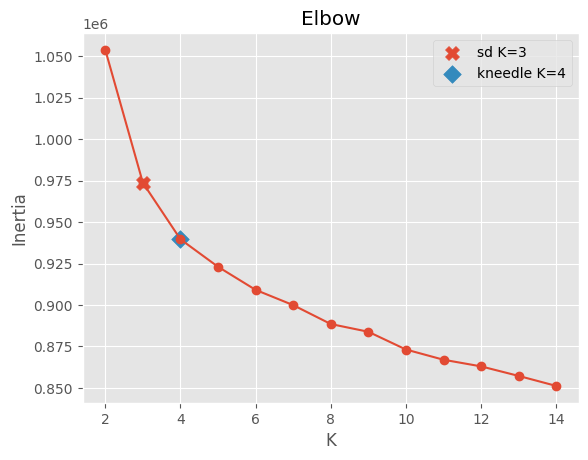

In [43]:
import math
import matplotlib.pyplot as plt

def elbows_from_inertia(ks, inertia):
    # ks: list of K values (e.g. list(range(2,15)))
    # inertia: list/1D-array of same length
    assert len(ks) == len(inertia), "ks and inertia must match length"
    # discrete second derivative
    S = {ks[i]: inertia[i-1] - 2*inertia[i] + inertia[i+1] for i in range(1, len(ks)-1)}
    k_sd = max(S, key=S.get)
    # kneedle (distance from line through endpoints)
    x1, y1 = ks[0], inertia[0]
    xN, yN = ks[-1], inertia[-1]
    denom = math.hypot((yN - y1), (xN - x1))
    assert denom > 0, "degenerate endpoints"
    dist = {k: abs((yN-y1)*k - (xN-x1)*inertia[idx] + xN*y1 - yN*x1)/denom
            for idx, k in enumerate(ks)}
    k_kneedle = max(dist, key=dist.get)

    print(f"second-derivative elbow => K = {k_sd}")
    print(f"kneedle elbow            => K = {k_kneedle}")

    plt.plot(ks, inertia, marker='o')
    plt.scatter([k_sd], [inertia[ks.index(k_sd)]], marker='X', s=100, label=f"sd K={k_sd}")
    plt.scatter([k_kneedle], [inertia[ks.index(k_kneedle)]], marker='D', s=80, label=f"kneedle K={k_kneedle}")
    plt.xlabel("K"); plt.ylabel("Inertia"); plt.title("Elbow"); plt.legend(); plt.grid(True)
    plt.show()

# --- usage with your reported numbers ---
ks = list(range(2, 15))

elbows_from_inertia(ks, inertia_list)


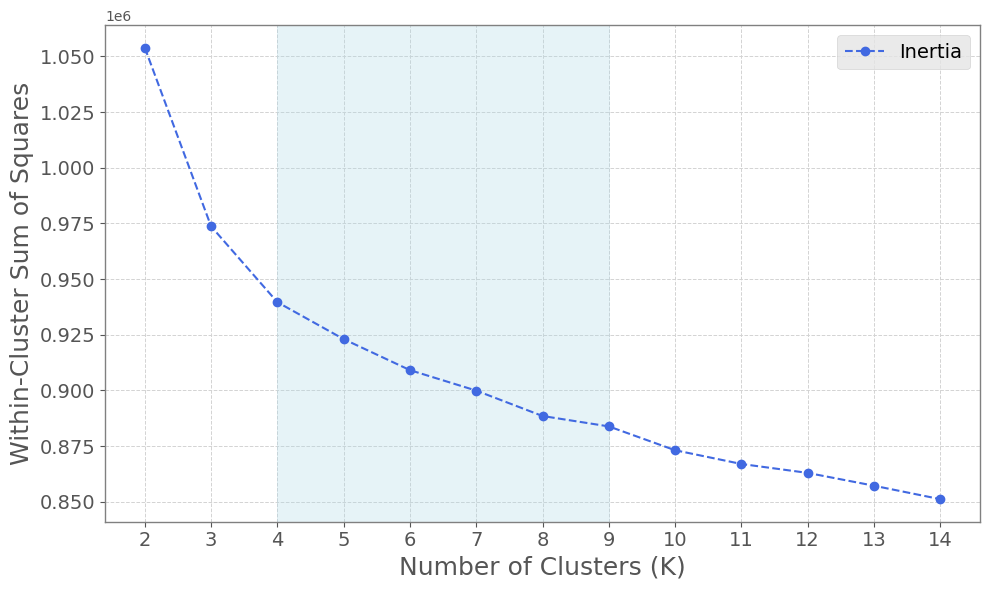

In [44]:
 #--- Plotting ---
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the entire elbow curve
ax.plot(k_values, inertia_list, marker='o', linestyle='--', color='royalblue', label='Inertia')

# Highlight the range K=5 to K=10
highlight_k_start = 4
highlight_k_end = 9
ax.axvspan(
    highlight_k_start , 
    highlight_k_end , 
    color='lightblue', 
    alpha=0.3, 
    # label=f'Range Used in Study (K={highlight_k_start}-{highlight_k_end})'
)

# Add an arrow and text to point out the "elbow"
# ax.annotate(
#     'Elbow Point',
#     xy=(4, inertia_list[2]), # Pointing to K=4
#     xytext=(5, inertia_list[2] + 0.1 * (max(inertia_list) - min(inertia_list))),
#     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
#     fontsize=12,
#     fontweight='bold'
# )


# --- Formatting ---
# ax.set_title('Elbow Plot for K-Means Clustering', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=18)
ax.set_ylabel('Within-Cluster Sum of Squares', fontsize=18)
ax.set_xticks(np.arange(min(k_values), max(k_values) + 1, 1))
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(True, which='both', linestyle='-', linewidth=0.5)
ax.legend(fontsize=14)
#set background color
ax.set_facecolor('white')
# grid color
ax.grid(color='lightgray', linestyle='--', linewidth=0.7)
#axis color
ax.spines['top'].set_color('gray')
ax.spines['right'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')
fig.tight_layout()
#save
fig.savefig('elbow_plot.png', dpi=300)
plt.show()

In [45]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Normality tests
from scipy.stats import shapiro, kruskal
from scipy.stats import levene  # For homogeneity of variance

# ----------------- USER/PLOTTING CONFIG -----------------
K_RANGE = range(4, 10)  # Iterate from K=4 to K=9
WIN_STEP = 5
TR = 0.8
KMEANS_RANDOM_STATE = 1
KMEANS_N_INIT = "auto"
KMEANS_MAX_ITER = 1000
PCA_RANDOM_STATE = 1

# Statistical test parameters
NORMALITY_ALPHA = 0.05  # Significance level for normality tests
VARIANCE_ALPHA = 0.05   # Significance level for variance homogeneity test
MIN_SAMPLE_SIZE = 3     # Minimum samples per group for normality testing

FIGSIZE = (8, 6)
PLOT_MARKER_SIZE = 60
PLOT_ALPHA = 0.8
PLOT_EDGECOLOR = "k"
PLOT_LINEWIDTH = 0.5
CENTROID_MARKER = "X"
CENTROID_SIZE = 200
CENTROID_TEXT_FONTSIZE = 16
CENTROID_TEXT_BBOX = dict(facecolor='k', alpha=0.6, boxstyle='round,pad=0.2')

# ---- sanity checks ----
if "all_data" not in globals() or "all_labels" not in globals():
    raise RuntimeError("Please define `all_data` (n_subjects x n_timepoints x n_features) and `all_labels` (n_subjects,) before running.")
if np.isnan(all_data).any():
    raise ValueError("all_data contains NaNs. Please clean or impute before running.")
if all_data.ndim != 3:
    raise ValueError("all_data must be shape (n_subjects, n_timepoints, n_features).")

n_subjects, n_timepoints, n_features = all_data.shape
print(f"Data: {n_subjects} subjects × {n_timepoints} timepoints × {n_features} features")

# ---------------- PREP DATA & SCALE ----------------
reshaped_data = all_data.reshape(-1, n_features)
print(f"Reshaped data for clustering / PCA: {reshaped_data.shape}")
X_scaled = reshaped_data  # Using raw data without scaling

# ---- Store results from all K iterations ----
all_anova_results = []
statistical_test_summary = []

def test_normality_and_variance(groups, state_id, k_clusters):
    """
    Test normality and homogeneity of variance for groups.
    Returns: (use_parametric, test_details)
    """
    test_details = {
        'state': state_id,
        'k': k_clusters,
        'n_groups': len(groups),
        'group_sizes': [len(g) for g in groups],
        'normality_test': 'Not performed',
        'variance_test': 'Not performed',
        'use_parametric': False,
        'reason': ''
    }
    
    # Check if we have enough data for normality testing
    if any(len(g) < MIN_SAMPLE_SIZE for g in groups):
        test_details['reason'] = f'Sample size too small (min {MIN_SAMPLE_SIZE} required)'
        test_details['use_parametric'] = False
        return False, test_details
    
    # Test normality for each group using Shapiro-Wilk
    normality_pvals = []
    for i, group in enumerate(groups):
        if len(group) >= 3:  # Shapiro-Wilk requires at least 3 samples
            try:
                _, p_val = shapiro(group)
                normality_pvals.append(p_val)
            except:
                normality_pvals.append(0.0)  # Assume non-normal if test fails
        else:
            normality_pvals.append(0.0)  # Too small for normality test
    
    # Check if all groups are normally distributed
    all_normal = all(p > NORMALITY_ALPHA for p in normality_pvals)
    test_details['normality_test'] = f"Shapiro-Wilk p-values: {[f'{p:.4f}' for p in normality_pvals]}"
    
    if not all_normal:
        test_details['reason'] = 'One or more groups not normally distributed'
        test_details['use_parametric'] = False
        return False, test_details
    
    # Test homogeneity of variance using Levene's test
    try:
        _, variance_p = levene(*groups)
        test_details['variance_test'] = f"Levene's test p-value: {variance_p:.4f}"
        
        if variance_p <= VARIANCE_ALPHA:
            test_details['reason'] = 'Unequal variances detected'
            test_details['use_parametric'] = False
            return False, test_details
        
    except:
        test_details['variance_test'] = 'Levene test failed'
        test_details['reason'] = 'Could not test variance homogeneity'
        test_details['use_parametric'] = False
        return False, test_details
    
    # All assumptions met
    test_details['reason'] = 'All parametric assumptions satisfied'
    test_details['use_parametric'] = True
    return True, test_details

# ---- Loop through all K values ----
for K_CLUSTERS in K_RANGE:
    print(f"\n{'='*60}")
    print(f"RUNNING ANALYSIS FOR K = {K_CLUSTERS}")
    print(f"{'='*60}")

    OUTFIG = Path(f'kmeans_pca_projection_k={K_CLUSTERS}.png')

    # ---------------- KMEANS (fit on all windows) ----------------
    kmeans = KMeans(
        n_clusters=K_CLUSTERS,
        random_state=KMEANS_RANDOM_STATE,
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER
    )
    cluster_labels_flat = kmeans.fit_predict(X_scaled)
    cluster_labels = cluster_labels_flat.reshape(n_subjects, n_timepoints)
    print(f"KMeans done for K={K_CLUSTERS} — cluster labels shape: {cluster_labels.shape}")

    # ---- dwell-time extraction per subject (seconds) ----
    def extract_dwell_time_features_for_subjects(cluster_labels_reshaped, k_clusters, win_step=WIN_STEP, tr=TR):
        dwell = np.zeros((cluster_labels_reshaped.shape[0], k_clusters), dtype=float)
        for s in range(cluster_labels_reshaped.shape[0]):
            seq = cluster_labels_reshaped[s]
            counts = np.bincount(seq, minlength=k_clusters)
            dwell[s, :] = counts * win_step * tr
        return dwell

    all_dwell_times = extract_dwell_time_features_for_subjects(cluster_labels, K_CLUSTERS, WIN_STEP, TR)

    # ----------------- STATISTICAL TESTING per state -----------------
    unique_labels = np.unique(all_labels)
    pvals = np.full(K_CLUSTERS, np.nan)
    test_types = np.full(K_CLUSTERS, 'None', dtype=object)
    tested_states = []

    for state in range(K_CLUSTERS):
        groups = [all_dwell_times[all_labels == label, state] for label in unique_labels]
        groups = [g for g in groups if g.size > 0]
        
        if len(groups) < 2 or np.std(np.concatenate(groups)) <= 1e-10:
            continue
        
        # Test assumptions and choose appropriate test
        use_parametric, test_details = test_normality_and_variance(groups, state, K_CLUSTERS)
        statistical_test_summary.append(test_details)
        
        if use_parametric:
            # Use ANOVA (F-test)
            f_stat, p_value = stats.f_oneway(*groups)
            test_types[state] = 'ANOVA'
            print(f"  State {state}: Using ANOVA (parametric assumptions met)")
        else:
            # Use Kruskal-Wallis (non-parametric)
            f_stat, p_value = kruskal(*groups)
            test_types[state] = 'Kruskal-Wallis'
            print(f"  State {state}: Using Kruskal-Wallis ({test_details['reason']})")
        
        pvals[state] = float(p_value)
        tested_states.append(state)

    # Apply FDR correction
    pvals_corrected = np.full_like(pvals, np.nan)
    sig_fdr_states = []
    if len(tested_states) > 0:
        tested_idx = np.array(tested_states, dtype=int)
        raw_p = pvals[tested_idx]
        rejected, pvals_corr_sub, _, _ = multipletests(raw_p, alpha=0.05, method="fdr_bh")
        pvals_corrected[tested_idx] = pvals_corr_sub
        sig_fdr_states = tested_idx[rejected].tolist()

    print(f"K={K_CLUSTERS}: Found {len(sig_fdr_states)} significant states after FDR correction.")

    # ----------------- PCA + PLOT -----------------
    pca = PCA(n_components=2, random_state=PCA_RANDOM_STATE)
    X2 = pca.fit_transform(X_scaled)
    centers2 = pca.transform(kmeans.cluster_centers_)
    labels = cluster_labels_flat

    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.scatter(X2[:, 0], X2[:, 1], c=labels, cmap='tab10', s=PLOT_MARKER_SIZE, alpha=PLOT_ALPHA, edgecolor=PLOT_EDGECOLOR, linewidth=PLOT_LINEWIDTH)
    ax.scatter(centers2[:, 0], centers2[:, 1], marker=CENTROID_MARKER, s=CENTROID_SIZE, c='k')
    for idx, (x, y) in enumerate(centers2):
        star = "*" if (idx in sig_fdr_states) else ""
        ax.text(x, y, f"{idx}{star}", color='w', fontsize=CENTROID_TEXT_FONTSIZE, fontweight='bold', ha='center', va='center', bbox=CENTROID_TEXT_BBOX)
    
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title(f'K-Means State Projection (K={K_CLUSTERS})', fontsize=14)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    fig.tight_layout()
    plt.savefig(OUTFIG, dpi=300, bbox_inches='tight')
    plt.close(fig)

    # ----------------- STORE RESULTS TABLE -----------------
    df_anova = pd.DataFrame({
        "state": np.arange(K_CLUSTERS),
        "test_type": test_types,
        "p_value": pvals,
        "p_value_corrected": pvals_corrected,
        "significant_fdr": [s in sig_fdr_states for s in range(K_CLUSTERS)]
    })
    all_anova_results.append({'k': K_CLUSTERS, 'results': df_anova})

# ----------------- FINAL SUMMARY OF ALL RESULTS -----------------
print(f"\n\n{'='*80}")
print("FINAL SUMMARY OF STATISTICAL ANALYSIS FOR ALL K VALUES")
print(f"{'='*80}")

for result in all_anova_results:
    k = result['k']
    df_res = result['results']
    n_sig = df_res['significant_fdr'].sum()
    
    print(f"\n--- K = {k} (Found {n_sig} significant states) ---")
    print(df_res.to_string(index=False))

# ----------------- STATISTICAL TEST ASSUMPTION SUMMARY -----------------
print(f"\n\n{'='*80}")
print("SUMMARY OF STATISTICAL TEST ASSUMPTIONS")
print(f"{'='*80}")

# Create summary DataFrame
test_summary_df = pd.DataFrame(statistical_test_summary)

if not test_summary_df.empty:
    # Count test types used
    parametric_count = test_summary_df['use_parametric'].sum()
    nonparametric_count = len(test_summary_df) - parametric_count
    
    print(f"\nOverall Test Usage:")
    print(f"  ANOVA (parametric): {parametric_count} states")
    print(f"  Kruskal-Wallis (non-parametric): {nonparametric_count} states")
    
    print(f"\nReasons for non-parametric tests:")
    reason_counts = test_summary_df[~test_summary_df['use_parametric']]['reason'].value_counts()
    for reason, count in reason_counts.items():
        print(f"  {reason}: {count} states")
    
    # Show detailed breakdown by K
    print(f"\nDetailed breakdown by K value:")
    for k in K_RANGE:
        k_data = test_summary_df[test_summary_df['k'] == k]
        if not k_data.empty:
            parametric_k = k_data['use_parametric'].sum()
            total_k = len(k_data)
            print(f"  K={k}: {parametric_k}/{total_k} states used ANOVA")

else:
    print("No statistical tests were performed.")

# Save detailed test assumption results
test_summary_df.to_csv('statistical_test_assumptions.csv', index=False)
print(f"\nDetailed test assumption results saved to 'statistical_test_assumptions.csv'")

Data: 68 subjects × 52 timepoints × 4950 features
Reshaped data for clustering / PCA: (3536, 4950)

RUNNING ANALYSIS FOR K = 4
KMeans done for K=4 — cluster labels shape: (68, 52)
  State 0: Using ANOVA (parametric assumptions met)
  State 1: Using ANOVA (parametric assumptions met)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
K=4: Found 1 significant states after FDR correction.

RUNNING ANALYSIS FOR K = 5
KMeans done for K=5 — cluster labels shape: (68, 52)
  State 0: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 1: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 4: Using Kruskal-Wallis (One or more groups not normally distributed)
K=5: Found 1 significant states aft

Data: 68 subjects × 52 timepoints × 4950 features
Using statistical tests with normality and variance checks (ANOVA/F-test vs Mann-Whitney U / Kruskal-Wallis)
Reshaped data for clustering / PCA: (3536, 4950)

RUNNING ANALYSIS FOR K = 4
  State 0: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 1: Using ANOVA (parametric assumptions met)
  State 2: Using ANOVA (parametric assumptions met)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
K=4: Found 1 significant states, plotting top 2.


/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,


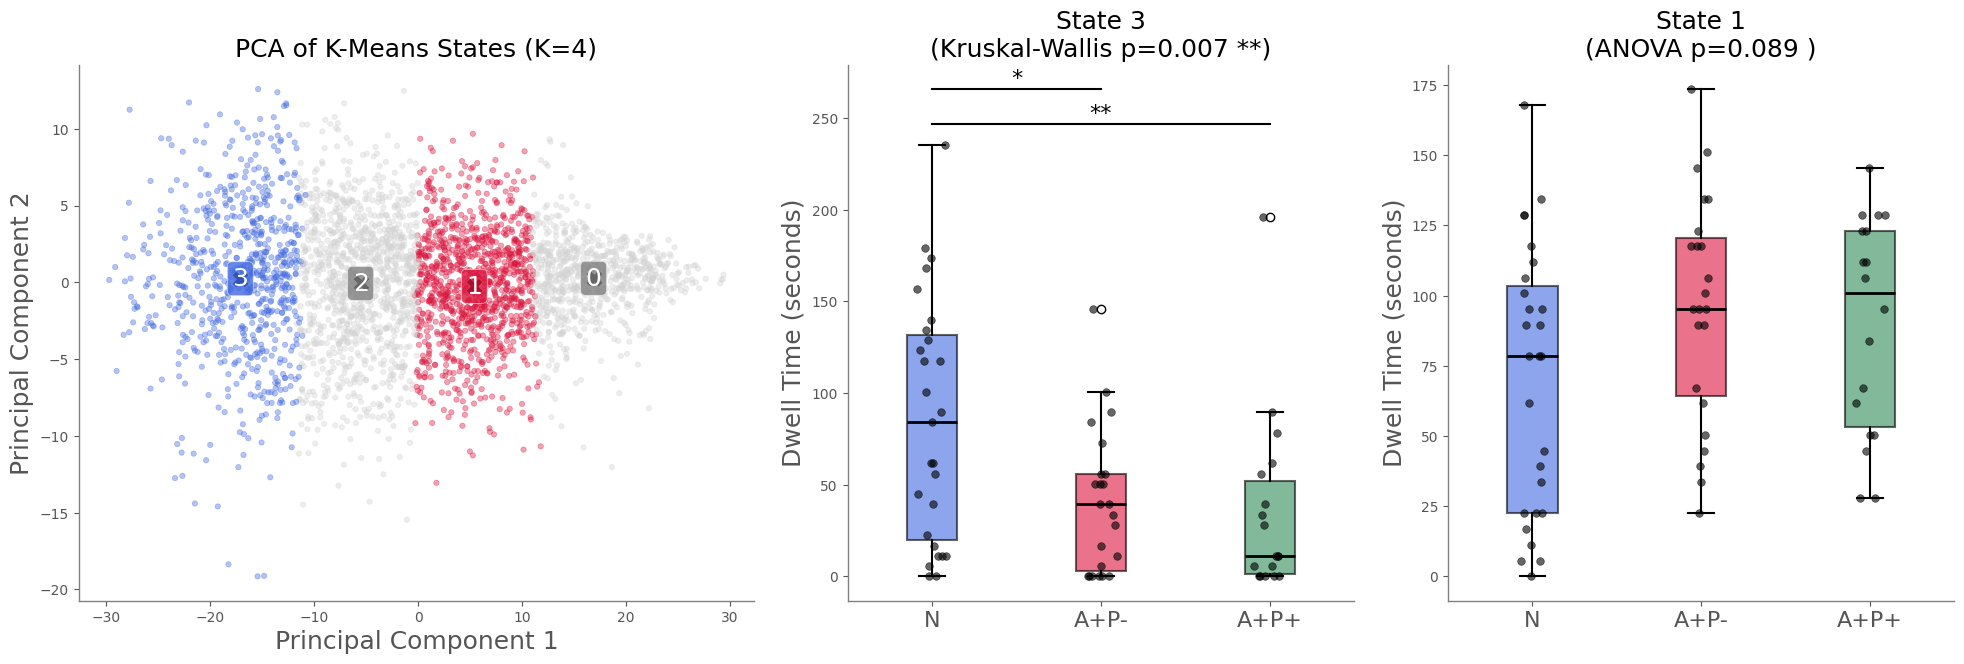


RUNNING ANALYSIS FOR K = 5
  State 0: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 1: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 4: Using Kruskal-Wallis (One or more groups not normally distributed)
K=5: Found 1 significant states, plotting top 2.


/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,


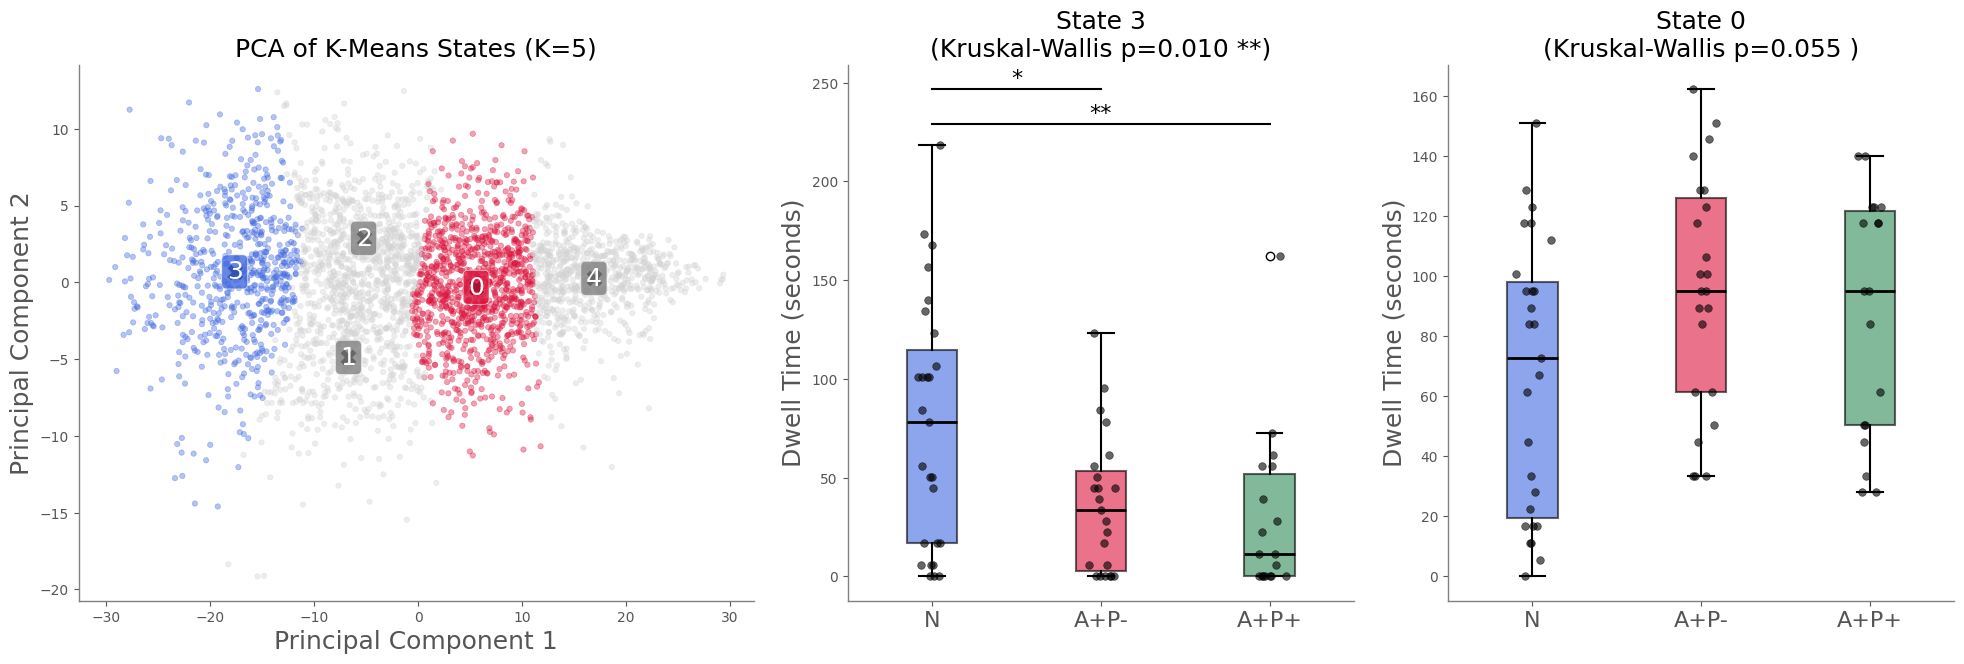


RUNNING ANALYSIS FOR K = 6
  State 0: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 1: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 4: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 5: Using Kruskal-Wallis (One or more groups not normally distributed)
K=6: Found 2 significant states, plotting top 2.


/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,


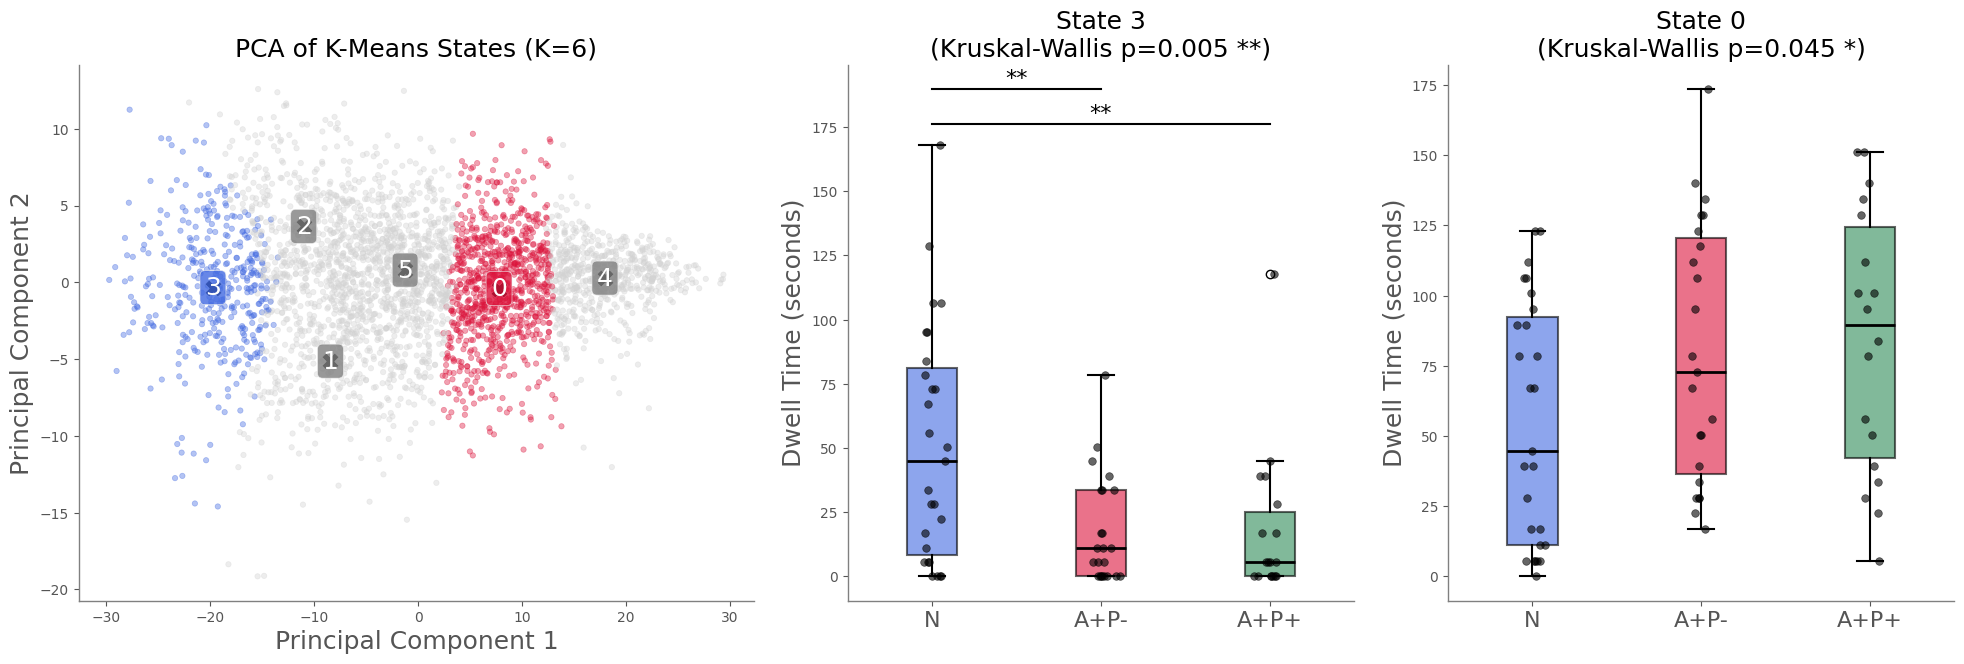


RUNNING ANALYSIS FOR K = 7
  State 0: Using ANOVA (parametric assumptions met)
  State 1: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 4: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 5: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 6: Using Kruskal-Wallis (One or more groups not normally distributed)
K=7: Found 2 significant states, plotting top 2.


/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,


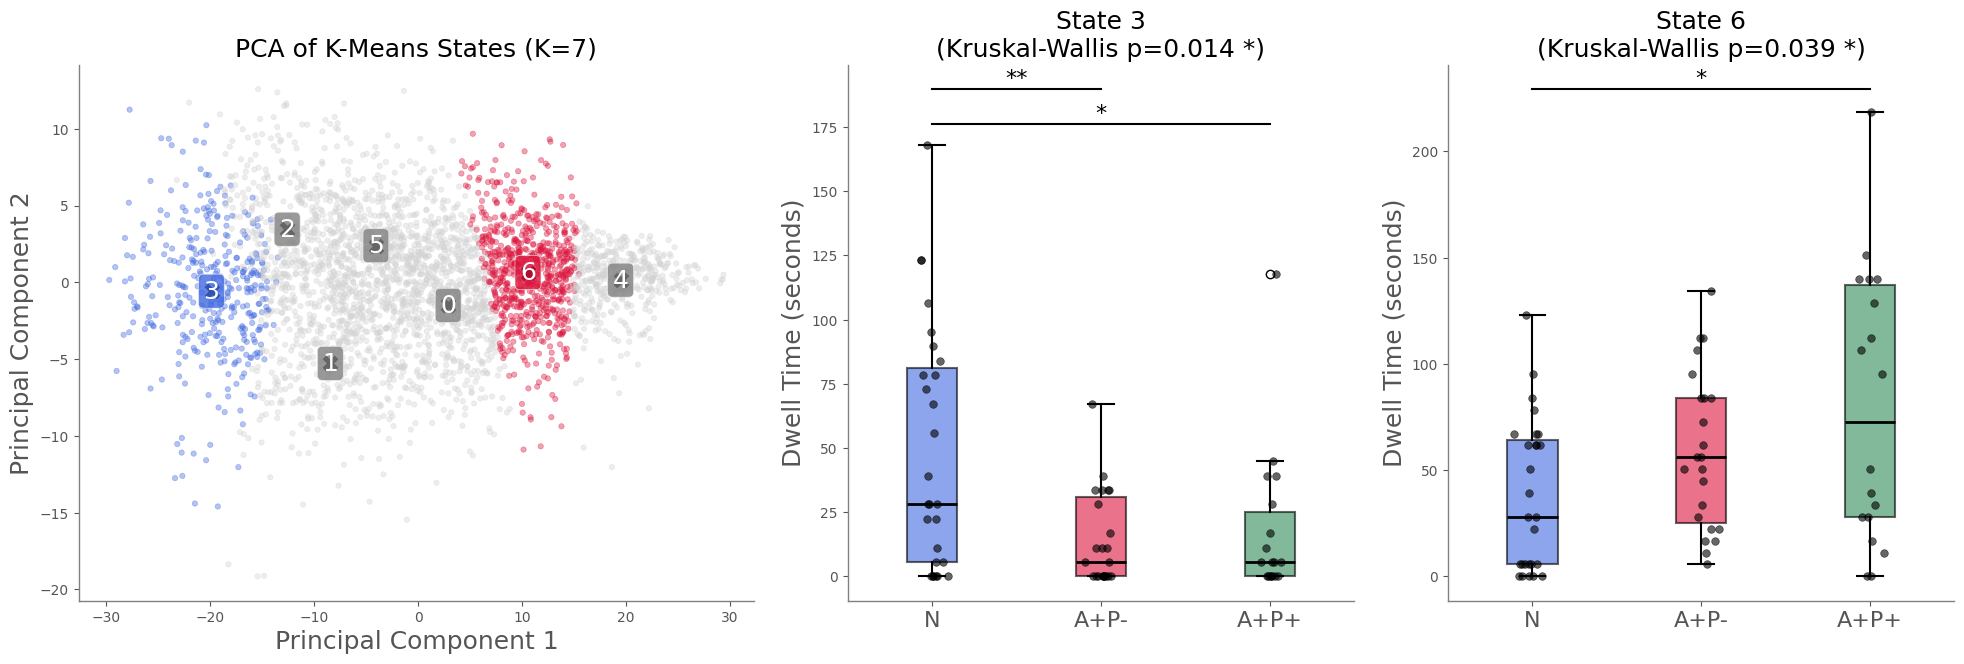


RUNNING ANALYSIS FOR K = 8
  State 0: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 1: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 4: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 5: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 6: Using ANOVA (parametric assumptions met)
  State 7: Using Kruskal-Wallis (One or more groups not normally distributed)
K=8: Found 2 significant states, plotting top 2.


/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,


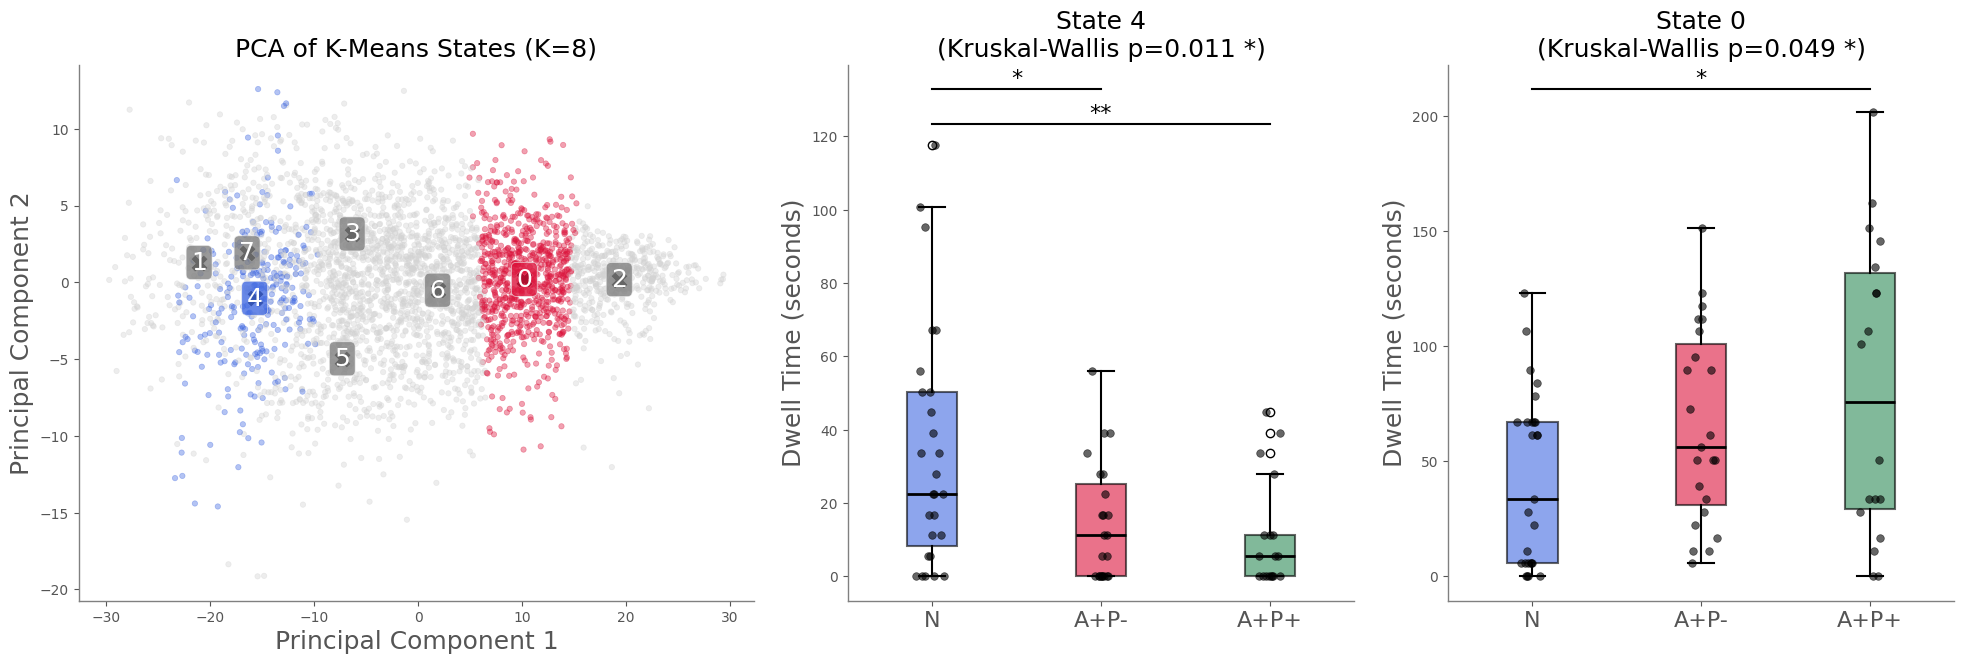


RUNNING ANALYSIS FOR K = 9
  State 0: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 1: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 2: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 3: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 4: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 5: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 6: Using ANOVA (parametric assumptions met)
  State 7: Using Kruskal-Wallis (One or more groups not normally distributed)
  State 8: Using Kruskal-Wallis (One or more groups not normally distributed)
K=9: Found 2 significant states, plotting top 2.


/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
/tmp/ipykernel_110877/1170049086.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,


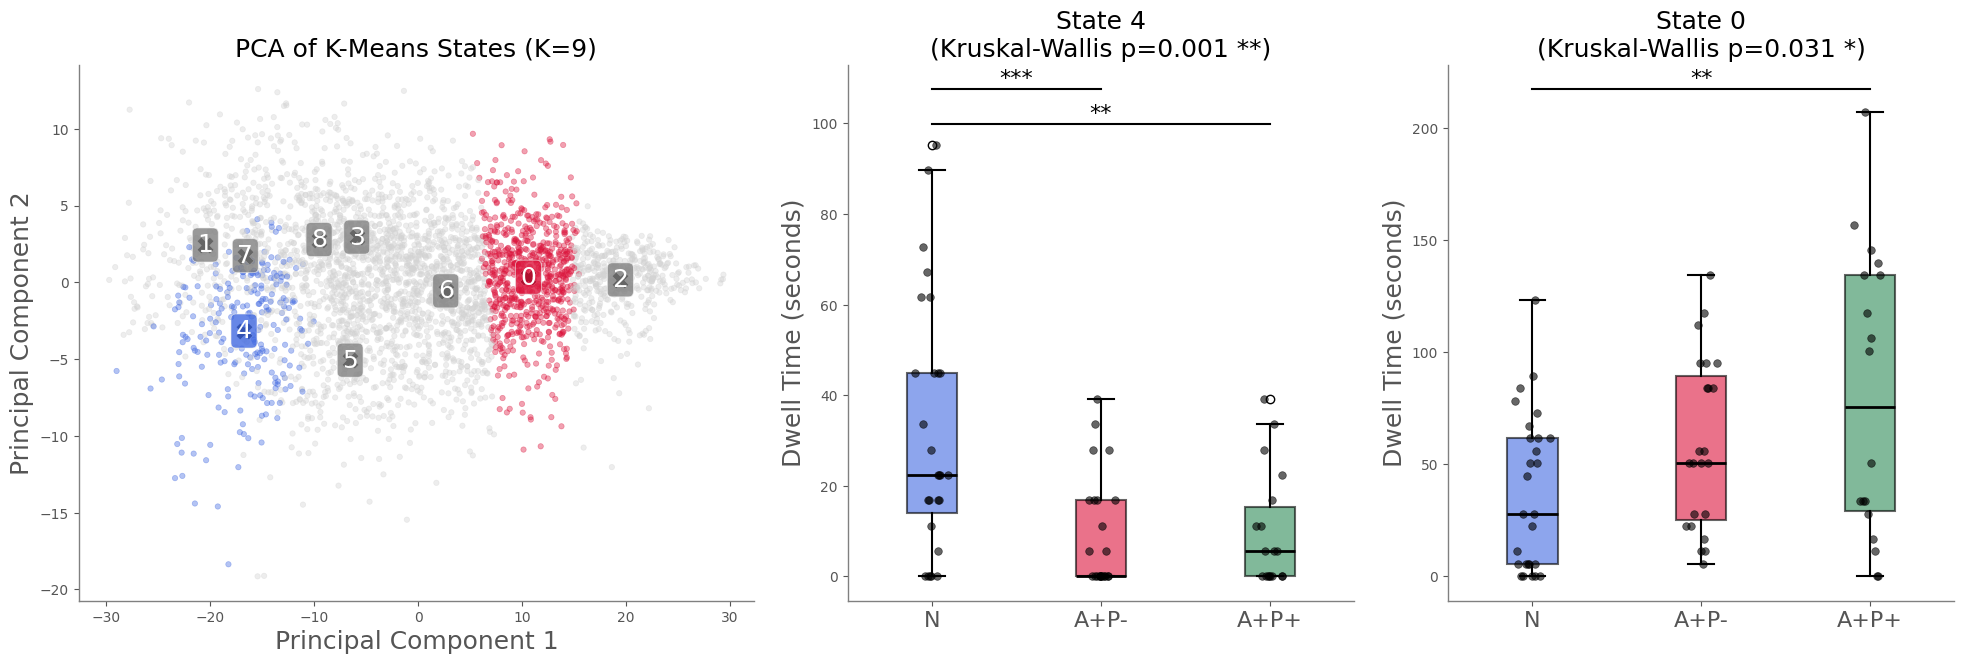



SUMMARY OF STATISTICAL TESTS USED (ADAPTIVE APPROACH)

Overall Test Usage:
  Kruskal-Wallis: 34 states
  ANOVA: 5 states

Parametric vs Non-parametric breakdown:
  Parametric tests (ANOVA/F-test): 5 states
  Non-parametric tests (Mann-Whitney/Kruskal-Wallis): 34 states

Reasons for non-parametric tests:
  One or more groups not normally distributed: 34 states

Detailed breakdown by K value:
  K=4: 2 ANOVA/F-test, 0 Mann-Whitney, 2 Kruskal-Wallis, 0 none (out of 4 total)
  K=5: 0 ANOVA/F-test, 0 Mann-Whitney, 5 Kruskal-Wallis, 0 none (out of 5 total)
  K=6: 0 ANOVA/F-test, 0 Mann-Whitney, 6 Kruskal-Wallis, 0 none (out of 6 total)
  K=7: 1 ANOVA/F-test, 0 Mann-Whitney, 6 Kruskal-Wallis, 0 none (out of 7 total)
  K=8: 1 ANOVA/F-test, 0 Mann-Whitney, 7 Kruskal-Wallis, 0 none (out of 8 total)
  K=9: 1 ANOVA/F-test, 0 Mann-Whitney, 8 Kruskal-Wallis, 0 none (out of 9 total)

Overall success rate: 100.0% of state comparisons used valid statistical tests

Detailed test results saved to 'combi

In [46]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Statistical tests (both parametric and non-parametric)
from scipy.stats import kruskal, mannwhitneyu, shapiro, levene

# ----------------- USER/PLOTTING CONFIG -----------------
K_RANGE = range(4, 10)
WIN_SEC = 60
OVERLAP_FRAC = 0.90
WIN_LEN = int(round(WIN_SEC / TR))          # 125
WIN_STEP    = int(round(WIN_LEN * (1.0 - OVERLAP_FRAC)))  # 112 # rational was that we need more windows!

STEP_SEC      = WIN_STEP * TR



TR = 0.8
KMEANS_RANDOM_STATE = 0
KMEANS_N_INIT = "auto"
KMEANS_MAX_ITER = 10000
PCA_RANDOM_STATE = 0
P_VALUE_THRESHOLD = 0.05 # Uncorrected p-value threshold for initial state selection
POSTHOC_ALPHA = 0.05 # Alpha for Tukey's HSD

# Statistical test parameters
NORMALITY_ALPHA = 0.05  # Significance level for normality tests
VARIANCE_ALPHA = 0.05   # Significance level for variance homogeneity test
MIN_SAMPLE_SIZE = 3     # Minimum samples per group for normality testing

# ---- Sanity checks ----
if "all_data" not in globals() or "all_labels" not in globals():
    raise RuntimeError("Please define `all_data` and `all_labels` before running.")
if np.isnan(all_data).any():
    raise ValueError("all_data contains NaNs. Please clean or impute before running.")

n_subjects, n_timepoints, n_features = all_data.shape
print(f"Data: {n_subjects} subjects × {n_timepoints} timepoints × {n_features} features")
print("Using statistical tests with normality and variance checks (ANOVA/F-test vs Mann-Whitney U / Kruskal-Wallis)")

# ---------------- PREP DATA ----------------
reshaped_data = all_data.reshape(-1, n_features)
X_scaled = reshaped_data
print(f"Reshaped data for clustering / PCA: {reshaped_data.shape}")

# Store statistical test results
all_statistical_results = []

def test_normality_and_variance(groups, state_id, k_clusters):
    """
    Test normality and homogeneity of variance for groups.
    Returns: (use_parametric, test_details)
    """
    test_details = {
        'state': state_id,
        'k': k_clusters,
        'n_groups': len(groups),
        'group_sizes': [len(g) for g in groups],
        'normality_test': 'Not performed',
        'variance_test': 'Not performed',
        'use_parametric': False,
        'reason': ''
    }
    
    # Check if we have enough data for normality testing
    if any(len(g) < MIN_SAMPLE_SIZE for g in groups):
        test_details['reason'] = f'Sample size too small (min {MIN_SAMPLE_SIZE} required)'
        test_details['use_parametric'] = False
        return False, test_details
    
    # Test normality for each group using Shapiro-Wilk
    normality_pvals = []
    for i, group in enumerate(groups):
        if len(group) >= 3:  # Shapiro-Wilk requires at least 3 samples
            try:
                _, p_val = shapiro(group)
                normality_pvals.append(p_val)
            except:
                normality_pvals.append(0.0)  # Assume non-normal if test fails
        else:
            normality_pvals.append(0.0)  # Too small for normality test
    
    # Check if all groups are normally distributed
    all_normal = all(p > NORMALITY_ALPHA for p in normality_pvals)
    test_details['normality_test'] = f"Shapiro-Wilk p-values: {[f'{p:.4f}' for p in normality_pvals]}"
    
    if not all_normal:
        test_details['reason'] = 'One or more groups not normally distributed'
        test_details['use_parametric'] = False
        return False, test_details
    
    # Test homogeneity of variance using Levene's test
    try:
        _, variance_p = levene(*groups)
        test_details['variance_test'] = f"Levene's test p-value: {variance_p:.4f}"
        
        if variance_p <= VARIANCE_ALPHA:
            test_details['reason'] = 'Unequal variances detected'
            test_details['use_parametric'] = False
            return False, test_details
        
    except:
        test_details['variance_test'] = 'Levene test failed'
        test_details['reason'] = 'Could not test variance homogeneity'
        test_details['use_parametric'] = False
        return False, test_details
    
    # All assumptions met
    test_details['reason'] = 'All parametric assumptions satisfied'
    test_details['use_parametric'] = True
    return True, test_details

def choose_statistical_test(groups, state_id, k_clusters):
    """
    Choose appropriate statistical test based on normality and variance assumptions.
    Returns: (test_type, p_value, f_statistic, test_details)
    """
    # Basic checks
    if len(groups) < 2 or any(g.size == 0 for g in groups):
        test_details = {
            'state': state_id, 'k': k_clusters, 'n_groups': len(groups),
            'group_sizes': [len(g) for g in groups], 'test_used': 'None',
            'reason': 'Insufficient groups or empty groups', 'use_parametric': False
        }
        return 'None', 1.0, 0.0, test_details
    
    if np.std(np.concatenate(groups)) <= 1e-10:
        test_details = {
            'state': state_id, 'k': k_clusters, 'n_groups': len(groups),
            'group_sizes': [len(g) for g in groups], 'test_used': 'None',
            'reason': 'No variance in data', 'use_parametric': False
        }
        return 'None', 1.0, 0.0, test_details
    
    # Check if any group has zero variance (all identical values)
    group_stds = [np.std(g) for g in groups]
    if any(std <= 1e-10 for std in group_stds):
        test_details = {
            'state': state_id, 'k': k_clusters, 'n_groups': len(groups),
            'group_sizes': [len(g) for g in groups], 'test_used': 'None',
            'reason': 'One or more groups has no variance', 'use_parametric': False
        }
        return 'None', 1.0, 0.0, test_details
    
    # Test assumptions and choose appropriate test
    use_parametric, test_details = test_normality_and_variance(groups, state_id, k_clusters)
    
    try:
        if use_parametric:
            # Use parametric tests (ANOVA for >2 groups, t-test for 2 groups)
            if len(groups) == 2:
                # For 2 groups, we could use independent t-test, but f_oneway works too
                f_stat, p_value = stats.f_oneway(*groups)
                test_details['test_used'] = 'F-test/ANOVA'
                print(f"  State {state_id}: Using F-test (parametric assumptions met)")
            else:
                # Use ANOVA (F-test) for >2 groups
                f_stat, p_value = stats.f_oneway(*groups)
                test_details['test_used'] = 'ANOVA'
                print(f"  State {state_id}: Using ANOVA (parametric assumptions met)")
            
            return test_details['test_used'], p_value, f_stat, test_details
        else:
            # Use non-parametric tests
            if len(groups) == 2:
                # Use Mann-Whitney U test for 2 groups
                statistic, p_value = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
                test_details['test_used'] = 'Mann-Whitney'
                print(f"  State {state_id}: Using Mann-Whitney U ({test_details['reason']})")
                return 'Mann-Whitney', p_value, statistic, test_details
            else:
                # Use Kruskal-Wallis for >2 groups
                statistic, p_value = kruskal(*groups)
                test_details['test_used'] = 'Kruskal-Wallis'
                print(f"  State {state_id}: Using Kruskal-Wallis ({test_details['reason']})")
                return 'Kruskal-Wallis', p_value, statistic, test_details
                
    except Exception as e:
        test_details['reason'] = f'Statistical test failed: {str(e)}'
        test_details['test_used'] = 'None'
        print(f"Warning: Statistical test failed for state {state_id}: {e}")
        return 'None', 1.0, 0.0, test_details

# ---- Loop through all K values ----
for K_CLUSTERS in K_RANGE:
    print(f"\n{'='*80}")
    print(f"RUNNING ANALYSIS FOR K = {K_CLUSTERS}")
    print(f"{'='*80}")

    # ---------------- KMEANS ----------------
    kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=KMEANS_RANDOM_STATE, 
                   n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
    cluster_labels_flat = kmeans.fit_predict(X_scaled)
    cluster_labels = cluster_labels_flat.reshape(n_subjects, n_timepoints)

    # ---- Dwell-time extraction ----
    def extract_dwell_time_features_for_subjects(cluster_labels_reshaped, k_clusters, win_step, tr):
        dwell = np.zeros((cluster_labels_reshaped.shape[0], k_clusters), dtype=float)
        for s in range(cluster_labels_reshaped.shape[0]):
            counts = np.bincount(cluster_labels_reshaped[s], minlength=k_clusters)
            dwell[s, :] = counts * win_step * tr
        return dwell

    all_dwell_times = extract_dwell_time_features_for_subjects(cluster_labels, K_CLUSTERS, WIN_STEP, TR)

    # ----------------- STATISTICAL TESTING and state selection -----------------
    unique_labels = np.unique(all_labels)
    all_states_stats = []
    
    for state in range(K_CLUSTERS):
        groups = [all_dwell_times[all_labels == label, state] for label in unique_labels]
        groups = [g for g in groups if g.size > 0]  # Remove empty groups
        
        # Choose appropriate statistical test based on assumptions
        test_type, p_value, f_stat, test_details = choose_statistical_test(
            groups, state, K_CLUSTERS)
        
        # Store statistical results
        all_statistical_results.append(test_details)
        
        if test_type != 'None':
            # Calculate means for coloring purposes
            mean_g0 = np.mean(groups[0]) if groups[0].size > 0 else 0
            mean_g1 = np.mean(groups[1]) if len(groups) > 1 and groups[1].size > 0 else 0
            
            all_states_stats.append({
                'state': state, 
                'p_value': p_value, 
                'f_statistic': f_stat,
                'test_type': test_type,
                'mean_g0': mean_g0, 
                'mean_g1': mean_g1
            })
    
    if not all_states_stats:
        print("No valid statistical tests performed for this K, skipping.")
        continue
    
    # Sort all states by p-value
    all_states_stats.sort(key=lambda x: x['p_value'])
    
    # Select states to plot
    significant_states = [s for s in all_states_stats if s['p_value'] < P_VALUE_THRESHOLD]
    top_states_to_plot = significant_states[:2]

    # For specific K values, ensure we have at least 2 states to plot
    if len(top_states_to_plot) < 2 and len(all_states_stats) >= 2:
        # Add the next best states (even if not significant)
        top_states_to_plot = all_states_stats[:2]

    print(f"K={K_CLUSTERS}: Found {len(significant_states)} significant states, plotting top {len(top_states_to_plot)}.")
    
    if not top_states_to_plot:
        print("No states to plot for this K, skipping figure generation.")
        continue

    # ----------------- SETUP COMBINED PLOT -----------------
    n_to_plot = len(top_states_to_plot)
    fig = plt.figure(figsize=(8 + 6 * n_to_plot, 7))
    gs = gridspec.GridSpec(1, 1 + n_to_plot, figure=fig, width_ratios=[8, *([6]*n_to_plot)])

    # ----------------- 1. PCA PLOT (LEFT) -----------------
    ax_pca = fig.add_subplot(gs[0, 0])
    pca = PCA(n_components=2, random_state=PCA_RANDOM_STATE)
    X2 = pca.fit_transform(X_scaled)
    centers2 = pca.transform(kmeans.cluster_centers_)
    
    # Color scheme based on mean differences
    cluster_colors = {res['state']: ('royalblue' if res['mean_g0'] > res['mean_g1'] else 'crimson') 
                     for res in top_states_to_plot}
    point_colors = [cluster_colors.get(l, '#D3D3D3') for l in cluster_labels_flat]
    
    ax_pca.scatter(X2[:, 0], X2[:, 1], c=point_colors, s=15, alpha=0.4)
    ax_pca.scatter(centers2[:, 0], centers2[:, 1], marker='X', s=150, c='k', 
                  edgecolors='white', linewidth=0.5)
    
    for idx, (x, y) in enumerate(centers2):
        color = cluster_colors.get(idx, 'gray')
        bbox_style = dict(facecolor=color, alpha=0.8, boxstyle='round,pad=0.2')
        ax_pca.text(x, y, f"{idx}", color='w', fontsize=18, ha='center', va='center', bbox=bbox_style)

    ax_pca.set_xlabel('Principal Component 1', fontsize=18)
    ax_pca.set_ylabel('Principal Component 2', fontsize=18)
    ax_pca.set_title(f'PCA of K-Means States (K={K_CLUSTERS})', fontsize=18)
    ax_pca.grid(True, linestyle='--', alpha=0.5)
    ax_pca.set_facecolor('white')
    for spine in ['top', 'right']:
        ax_pca.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax_pca.spines[spine].set_color('gray')

    # ----------------- 2. BOX PLOTS (RIGHT) WITH POST-HOC TESTING -----------------
    label_mapping = {0: 'N', 1: 'A+P-', 2: 'A+P+'}
    group_colors = {'N': 'royalblue', 'A+P-': 'crimson', 'A+P+': 'seagreen'}

    for i, result in enumerate(top_states_to_plot):
        ax_box = fig.add_subplot(gs[0, 1 + i])
        state = result['state']
        
        plot_data = [all_dwell_times[all_labels == label, state] for label in unique_labels]
        plot_labels = [label_mapping.get(label, f'Group {label}') for label in unique_labels]
        
        # Create boxplot
        bp = ax_box.boxplot(plot_data, patch_artist=True, labels=plot_labels,
                          boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                          capprops=dict(linewidth=1.5), medianprops=dict(linewidth=2, color='black'))
        
        for patch, label in zip(bp['boxes'], plot_labels):
            patch.set_facecolor(group_colors.get(label, 'gray'))
            patch.set_alpha(0.6)

        # Add individual data points with jitter
        for j, data in enumerate(plot_data):
            x_jitter = np.random.normal(j + 1, 0.04, size=len(data))
            ax_box.scatter(x_jitter, data, alpha=0.6, s=30, color='k', zorder=3)

        # Create title with test information
        test_type = result['test_type']
        p_val = result['p_value']
        sig_level = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        title_text = f'State {state}\n({test_type} p={p_val:.3f} {sig_level})'
        
        ax_box.set_title(title_text, fontsize=18)
        ax_box.set_ylabel('Dwell Time (seconds)', fontsize=18)
        ax_box.tick_params(axis='x', labelsize=16)
        ax_box.grid(True, alpha=0.3, axis='y')
        ax_box.set_facecolor('white')
        for spine in ['top', 'right']:
            ax_box.spines[spine].set_visible(False)
        for spine in ['left', 'bottom']:
            ax_box.spines[spine].set_color('gray')

        # --- Post-hoc Testing (only if main test is significant) ---
        if p_val < P_VALUE_THRESHOLD and len(np.unique(plot_labels)) > 2:
            # Prepare data for post-hoc test
            tukey_data = np.concatenate(plot_data)
            tukey_labels = np.concatenate([[label] * len(d) for label, d in zip(plot_labels, plot_data)])
            
            try:
                # Use Tukey's HSD for post-hoc comparisons
                tukey_result = pairwise_tukeyhsd(endog=tukey_data, groups=tukey_labels, alpha=POSTHOC_ALPHA)
                tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], 
                                      columns=tukey_result._results_table.data[0])
                
                # Plot significance bars
                y_max = max([d.max() for d in plot_data if d.size > 0])
                y_pos = y_max * 1.05
                y_step = y_max * 0.08
                
                for _, row in tukey_df.iterrows():
                    if row['reject']:  # If the pair is significant
                        group1, group2 = row['group1'], row['group2']
                        p_adj = row['p-adj']
                        
                        sig_level = '***' if p_adj < 0.001 else ('**' if p_adj < 0.01 else '*')

                        try:
                            x1 = plot_labels.index(group1) + 1
                            x2 = plot_labels.index(group2) + 1
                            
                            # Plot significance bar
                            ax_box.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=1.5)
                            ax_box.text((x1 + x2) / 2, y_pos, sig_level, ha='center', va='bottom', fontsize=16)
                            y_pos += y_step
                        except ValueError:
                            continue
                            
            except Exception as e:
                print(f"    Warning: Post-hoc test failed for state {state}: {e}")

    # --- Finalize and Save ---
    fig.tight_layout(pad=2.0)
    
    OUTFIG_COMBINED = Path(f'combined_analysis_k={K_CLUSTERS}_adaptive_tests.png')
    plt.savefig(OUTFIG_COMBINED, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# ----------------- SUMMARY OF STATISTICAL TESTS USED -----------------
print(f"\n\n{'='*80}")
print("SUMMARY OF STATISTICAL TESTS USED (ADAPTIVE APPROACH)")
print(f"{'='*80}")

if all_statistical_results:
    # Create summary DataFrame
    test_summary_df = pd.DataFrame(all_statistical_results)
    
    # Count test types used
    test_counts = test_summary_df['test_used'].value_counts()
    
    print(f"\nOverall Test Usage:")
    for test_type, count in test_counts.items():
        print(f"  {test_type}: {count} states")
    
    # Count parametric vs non-parametric
    parametric_count = test_summary_df['use_parametric'].sum()
    nonparametric_count = len(test_summary_df) - parametric_count
    
    print(f"\nParametric vs Non-parametric breakdown:")
    print(f"  Parametric tests (ANOVA/F-test): {parametric_count} states")
    print(f"  Non-parametric tests (Mann-Whitney/Kruskal-Wallis): {nonparametric_count} states")
    
    print(f"\nReasons for non-parametric tests:")
    nonparametric_df = test_summary_df[~test_summary_df['use_parametric']]
    if not nonparametric_df.empty:
        reason_counts = nonparametric_df['reason'].value_counts()
        for reason, count in reason_counts.items():
            print(f"  {reason}: {count} states")
    
    # Show detailed breakdown by K
    print(f"\nDetailed breakdown by K value:")
    for k in K_RANGE:
        k_data = test_summary_df[test_summary_df['k'] == k]
        if not k_data.empty:
            anova_count = ((k_data['test_used'] == 'ANOVA') | (k_data['test_used'] == 'F-test/ANOVA')).sum()
            mann_whitney_count = (k_data['test_used'] == 'Mann-Whitney').sum()
            kruskal_wallis_count = (k_data['test_used'] == 'Kruskal-Wallis').sum()
            none_count = (k_data['test_used'] == 'None').sum()
            total_k = len(k_data)
            
            print(f"  K={k}: {anova_count} ANOVA/F-test, {mann_whitney_count} Mann-Whitney, {kruskal_wallis_count} Kruskal-Wallis, {none_count} none (out of {total_k} total)")

    # Calculate percentage of successful tests
    successful_tests = test_summary_df[test_summary_df['test_used'] != 'None']
    if len(successful_tests) > 0:
        success_rate = len(successful_tests) / len(test_summary_df) * 100
        print(f"\nOverall success rate: {success_rate:.1f}% of state comparisons used valid statistical tests")
    
    # Save detailed results
    test_summary_df.to_csv('combined_analysis_statistical_tests_adaptive.csv', index=False)
    print(f"\nDetailed test results saved to 'combined_analysis_statistical_tests_adaptive.csv'")

print("\n\nCombined analysis complete with adaptive statistical testing!")
print("✓ Used parametric tests when assumptions were met, non-parametric otherwise")
print("✓ Included normality testing (Shapiro-Wilk) and variance homogeneity testing (Levene's test)")

In [7]:
# #!/usr/bin/env python3
# # -*- coding: utf-8 -*-

# import numpy as np
# import pandas as pd
# import nibabel as nib
# from pathlib import Path
# from scipy import stats
# from collections import Counter
# from sklearn.cluster import KMeans
# from statsmodels.stats.multitest import multipletests
# from nilearn.plotting import plot_img_on_surf, show
# import templateflow.api as tf
# import warnings
# import matplotlib.pyplot as plt
# import os
# from scipy.stats import kruskal, shapiro, levene

# # ================================================================================================
# # CONFIGURATION
# # ================================================================================================

# BASE_DIR = ""
# CONN_DIR = os.path.join(BASE_DIR, "subject_windows_confounds_old_60sec")

# # MULTIPLE SEEDS FOR ROBUST RESULTS
# SEED_LIST = [100, 200, 300, 400 ,500]  # Multiple seeds for K-means initialization

# # Analysis parameters
# K_RANGE = range(4, 10)  # The range of K values to analyze
# P_VALUE_THRESHOLD = 0.05  # Use uncorrected p-value
# KMEANS_N_INIT = "auto"
# KMEANS_MAX_ITER = 100000
# WIN_STEP = 5
# TR = 0.8
# HUB_THRESHOLD_STD = 2.0  # Number of std deviations for hub threshold

# # Statistical test parameters
# NORMALITY_ALPHA = 0.05
# VARIANCE_ALPHA = 0.05
# MIN_SAMPLE_SIZE = 3

# # ================================================================================================
# # DATA LOADING
# # ================================================================================================

# print("Loading data...")
# list_of_files = os.listdir(CONN_DIR)
# print(f"Found {len(list_of_files)} files")

# all_data = []
# all_labels = []
# for file in list_of_files:
#     if file.endswith(".npz"):
#         data = np.load(os.path.join(CONN_DIR, file))
        
#         AP_temp = data["AP"]
#         PA_temp = data["PA"]
#         label = data["label"]
        
#         sub_data = np.concatenate((AP_temp, PA_temp), axis=0)
        
#         all_data.append(sub_data)
#         all_labels.append(label)

# all_data = np.array(all_data)
# all_labels = np.array(all_labels)

# n_subjects, n_timepoints, n_features = all_data.shape
# print(f"Data loaded: {n_subjects} subjects × {n_timepoints} timepoints × {n_features} features")

# # ================================================================================================
# # ATLAS LOADING
# # ================================================================================================

# print("Loading atlas information...")
# try:
#     # Load Schaefer atlas information
#     atlas_path = tf.get(
#         template='MNI152NLin2009cAsym', atlas='Schaefer2018',
#         desc='100Parcels7Networks', extension='.tsv'
#     )
#     atlas_df = pd.read_csv(atlas_path, sep='\t')
    
#     # Load the atlas image file
#     atlas_img_path = tf.get(
#         template='MNI152NLin2009cAsym', atlas='Schaefer2018',
#         desc='100Parcels7Networks', resolution=2, extension='.nii.gz'
#     )
#     atlas_img = nib.load(str(atlas_img_path))
    
#     print("Atlas information loaded successfully.")

# except Exception as e:
#     print(f"Error loading atlas information: {e}")
#     atlas_df = None

# # ================================================================================================
# # HELPER FUNCTIONS
# # ================================================================================================

# # Dictionary to map network abbreviations to full names
# NETWORK_MAP = {
#     "Vis": "Visual",
#     "SomMot": "Somatomotor",
#     "DorsAttn": "Dorsal Attention",
#     "SalVentAttn": "Salience/Ventral Attention",
#     "Limbic": "Limbic",
#     "Cont": "Control",
#     "Default": "Default Mode"
# }

# def get_roi_info_detailed(roi_idx):
#     """Get detailed, unabbreviated information about a ROI, including hemisphere."""
#     if atlas_df is None or roi_idx >= len(atlas_df):
#         return {
#             'hemisphere': 'N/A',
#             'network_full': 'Unknown',
#             'region_full': f'ROI_{roi_idx}',
#         }
    
#     # Original name from atlas, e.g., '7Networks_LH_Default_pCunPCC_1'
#     original_name = atlas_df.loc[roi_idx, 'name']
    
#     # Remove the '7Networks_' prefix
#     name_parts = original_name.replace('7Networks_', '').split('_')
    
#     hemisphere = name_parts[0]
#     network_abbr = name_parts[1]
#     region_parts = name_parts[2:]
    
#     network_full = NETWORK_MAP.get(network_abbr, network_abbr)
#     region_full = "_".join(region_parts)

#     return {
#         'hemisphere': hemisphere,
#         'network_full': network_full,
#         'region_full': region_full,
#     }

# def get_group_name(label):
#     """Map numeric labels to group names."""
#     group_names = {0: 'N', 1: 'A+P-', 2: 'A+P+'}
#     return group_names.get(label, f'Group_{label}')

# def get_state_connectivity_matrix(cluster_center, n_rois):
#     """Convert cluster center vector to connectivity matrix."""
#     conn_matrix = np.zeros((n_rois, n_rois))
#     idx = 0
#     for i in range(n_rois):
#         for j in range(i + 1, n_rois):
#             conn_matrix[i, j] = conn_matrix[j, i] = cluster_center[idx]
#             idx += 1
#     return conn_matrix

# def test_assumptions_and_choose_test(groups, state_id, k_clusters):
#     """Test assumptions and choose appropriate statistical test."""
#     test_details = {
#         'state': state_id,
#         'k': k_clusters,
#         'n_groups': len(groups),
#         'group_sizes': [len(g) for g in groups],
#         'test_used': 'None',
#         'reason': 'Not tested'
#     }
    
#     # Basic checks
#     if len(groups) < 2 or any(g.size == 0 for g in groups):
#         return 'None', 1.0, 0.0, test_details
    
#     if np.std(np.concatenate(groups)) <= 1e-10:
#         test_details['reason'] = 'No variance in data'
#         return 'None', 1.0, 0.0, test_details
    
#     # Check sample sizes for normality testing
#     if any(len(g) < MIN_SAMPLE_SIZE for g in groups):
#         test_details['reason'] = f'Sample size too small (min {MIN_SAMPLE_SIZE})'
#         test_details['test_used'] = 'Kruskal-Wallis'
#         try:
#             f_stat, p_value = kruskal(*groups)
#         except:
#             return 'None', 1.0, 0.0, test_details
#         return 'Kruskal-Wallis', p_value, f_stat, test_details
    
#     # Test normality for each group
#     normality_pvals = []
#     for group in groups:
#         try:
#             _, p_val = shapiro(group)
#             normality_pvals.append(p_val)
#         except:
#             normality_pvals.append(0.0)
    
#     all_normal = all(p > NORMALITY_ALPHA for p in normality_pvals)
    
#     if not all_normal:
#         test_details['reason'] = 'One or more groups not normally distributed'
#         test_details['test_used'] = 'Kruskal-Wallis'
#         try:
#             f_stat, p_value = kruskal(*groups)
#         except:
#             return 'None', 1.0, 0.0, test_details
#         return 'Kruskal-Wallis', p_value, f_stat, test_details
    
#     # Test homogeneity of variance
#     try:
#         _, variance_p = levene(*groups)
#         if variance_p <= VARIANCE_ALPHA:
#             test_details['reason'] = 'Unequal variances detected'
#             test_details['test_used'] = 'Kruskal-Wallis'
#             f_stat, p_value = kruskal(*groups)
#             return 'Kruskal-Wallis', p_value, f_stat, test_details
#     except:
#         test_details['reason'] = 'Could not test variance homogeneity'
#         test_details['test_used'] = 'Kruskal-Wallis'
#         try:
#             f_stat, p_value = kruskal(*groups)
#         except:
#             return 'None', 1.0, 0.0, test_details
#         return 'Kruskal-Wallis', p_value, f_stat, test_details
    
#     # All assumptions met - use ANOVA
#     test_details['reason'] = 'All parametric assumptions satisfied'
#     test_details['test_used'] = 'ANOVA'
#     try:
#         f_stat, p_value = stats.f_oneway(*groups)
#     except:
#         return 'None', 1.0, 0.0, test_details
#     return 'ANOVA', p_value, f_stat, test_details

# # ================================================================================================
# # MULTI-SEED GLOBAL HUB ANALYSIS
# # ================================================================================================

# def analyze_global_state_hubs_multi_seed():
#     """
#     MULTI-SEED ANALYSIS: Analyze connectivity patterns across multiple K-means seeds
#     """
#     # Store global hub results across all seeds
#     all_global_hub_results = []
#     all_statistical_results = []
    
#     # Estimate number of ROIs from data shape
#     n_connections = all_data.shape[-1]
#     n_rois = int((1 + np.sqrt(1 + 8 * n_connections)) / 2)
#     print(f"Estimated {n_rois} ROIs from {n_connections} connections.")
#     print(f"Using {len(SEED_LIST)} seeds: {SEED_LIST}")
    
#     # Loop through all K values
#     for K_CLUSTERS in K_RANGE:
#         print(f"\n{'='*100}")
#         print(f"ANALYZING FOR K = {K_CLUSTERS} ACROSS {len(SEED_LIST)} SEEDS")
#         print(f"{'='*100}")
        
#         # Store results for this K across all seeds
#         k_results_across_seeds = []
        
#         # Loop through all seeds
#         for seed_idx, SEED in enumerate(SEED_LIST):
#             print(f"\n{'-'*60}")
#             print(f"SEED {seed_idx + 1}/{len(SEED_LIST)}: {SEED}")
#             print(f"{'-'*60}")

#             # 1. K-Means Clustering with current seed
#             reshaped_data = all_data.reshape(-1, n_features)
#             kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=SEED, 
#                            n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
#             cluster_labels_flat = kmeans.fit_predict(reshaped_data)
#             cluster_labels_reshaped = cluster_labels_flat.reshape(n_subjects, n_timepoints)

#             # 2. Dwell Time Extraction
#             dwell_times = np.array([np.bincount(seq, minlength=K_CLUSTERS) * WIN_STEP * TR 
#                                    for seq in cluster_labels_reshaped])

#             # 3. Statistical testing to find significant states for this seed
#             unique_labels = np.unique(all_labels)
#             significant_states = []
            
#             for state in range(K_CLUSTERS):
#                 groups = [dwell_times[all_labels == label, state] for label in unique_labels]
#                 groups = [g for g in groups if g.size > 0]  # Remove empty groups
                
#                 if len(groups) < 2:
#                     continue
                    
#                 # Test assumptions and perform appropriate statistical test
#                 test_type, p_value, f_stat, test_details = test_assumptions_and_choose_test(
#                     groups, state, K_CLUSTERS)
                
#                 # Add seed information to test details
#                 test_details['seed'] = SEED
#                 all_statistical_results.append(test_details)
                
#                 if test_type != 'None' and p_value < P_VALUE_THRESHOLD:
#                     significant_states.append(state)
#                     print(f"    State {state}: {test_type}, p={p_value:.4f} - SIGNIFICANT")
#                 elif test_type != 'None':
#                     print(f"    State {state}: {test_type}, p={p_value:.4f}")
            
#             print(f"    Found {len(significant_states)} significant states for K={K_CLUSTERS}, Seed={SEED}")

#             # 4. Global hub analysis for each significant state in this seed
#             seed_hub_results = []
#             for state in significant_states:
#                 # Determine dwell time direction for this specific state
#                 mean_dt_N = np.mean(dwell_times[all_labels == 0, state])
#                 mean_dt_patients = np.mean(dwell_times[all_labels > 0, state])
                
#                 direction = "N_higher" if mean_dt_N > mean_dt_patients else "N_lower"
                
#                 print(f"    State {state} ({direction}): N={mean_dt_N:.2f}s, Patients={mean_dt_patients:.2f}s")
                
#                 # **KEY: Use ALL windows assigned to this state**
#                 state_matrices = reshaped_data[cluster_labels_flat == state]
                
#                 if len(state_matrices) == 0:
#                     continue

#                 # Global mean connectivity for this state
#                 global_mean_vector = np.mean(state_matrices, axis=0)
#                 global_mean_matrix = get_state_connectivity_matrix(global_mean_vector, n_rois)
                
#                 # Hub identification using global threshold
#                 threshold = np.median(global_mean_matrix) + HUB_THRESHOLD_STD * np.std(global_mean_matrix)
#                 global_binary_matrix = (global_mean_matrix > threshold).astype(int)
#                 np.fill_diagonal(global_binary_matrix, 0)
#                 hubness_scores = np.sum(global_binary_matrix, axis=1) / (n_rois - 1)
                
#                 # Top 10 hubs for this state
#                 top_10_indices = np.argsort(hubness_scores)[::-1][:10]
                
#                 print(f"      Top 5 hubs:")
#                 for i, roi_idx in enumerate(top_10_indices[:5]):
#                     roi_info = get_roi_info_detailed(roi_idx)
#                     score = hubness_scores[roi_idx]
#                     print(f"        {i+1}. ROI {roi_idx} (score={score:.3f}): {roi_info['hemisphere']} {roi_info['network_full']}")
                
#                 # Store hub results for this seed
#                 for roi_idx in top_10_indices:
#                     seed_hub_results.append({
#                         'roi_index': roi_idx,
#                         'k': K_CLUSTERS,
#                         'state': state,
#                         'seed': SEED,
#                         'direction': direction,
#                         'hubness_score': hubness_scores[roi_idx],
#                         'state_id': f"K{K_CLUSTERS}_S{state}_Seed{SEED}",
#                         'mean_dt_N': mean_dt_N,
#                         'mean_dt_patients': mean_dt_patients
#                     })
            
#             k_results_across_seeds.extend(seed_hub_results)
        
#         # Add all results for this K to the global results
#         all_global_hub_results.extend(k_results_across_seeds)
        
#         print(f"\nSUMMARY FOR K={K_CLUSTERS}:")
#         print(f"  Total hub instances across all seeds: {len(k_results_across_seeds)}")
#         if k_results_across_seeds:
#             k_df = pd.DataFrame(k_results_across_seeds)
#             direction_counts = k_df['direction'].value_counts()
#             seed_counts = k_df['seed'].value_counts()
#             print(f"  Direction distribution: {dict(direction_counts)}")
#             print(f"  Seed distribution: {dict(seed_counts)}")
    
#     return all_global_hub_results, all_statistical_results

# def analyze_direction_specific_hubs_multi_seed(hub_df, title, color):
#     """Analyze hub patterns for a specific direction across multiple seeds."""
#     print(f"\n{'='*120}")
#     print(f"MULTI-SEED HUB ANALYSIS: {title}")
#     print(f"{'='*120}")
    
#     if hub_df.empty:
#         print("No hubs found for this direction.")
#         return
    
#     # Show seed-level summary
#     seed_summary = hub_df.groupby('seed').agg({
#         'roi_index': 'count',
#         'state_id': 'nunique'
#     }).rename(columns={'roi_index': 'n_hubs', 'state_id': 'n_unique_states'})
    
#     print(f"\nSeed-level summary:")
#     for seed, row in seed_summary.iterrows():
#         print(f"  Seed {seed}: {row['n_hubs']} hub instances from {row['n_unique_states']} unique states")
    
#     # Show state-level summary across seeds
#     state_summary = hub_df.groupby('state_id').agg({
#         'roi_index': 'count',
#         'k': 'first',
#         'state': 'first',
#         'seed': 'first',
#         'mean_dt_N': 'first',
#         'mean_dt_patients': 'first'
#     }).rename(columns={'roi_index': 'n_hubs'})
    
#     print(f"\nStates contributing to this analysis:")
#     for state_id, row in state_summary.iterrows():
#         print(f"  {state_id}: K={row['k']}, State={row['state']}, Seed={row['seed']}, Mean_DT_N={row['mean_dt_N']:.2f}s, Mean_DT_Patients={row['mean_dt_patients']:.2f}s")
    
#     # **MULTI-SEED: Hub consistency analysis across seeds**
#     roi_counts = Counter(hub_df['roi_index'])
#     top_15_consistent_hubs = roi_counts.most_common(15)
    
#     print(f"\nTop 15 Most Consistent Hub Regions Across Seeds:")
#     print(f"Based on {len(hub_df)} total hub instances from {len(state_summary)} unique states across {len(seed_summary)} seeds")
    
#     for rank, (roi_idx, frequency) in enumerate(top_15_consistent_hubs):
#         n_states = hub_df[hub_df['roi_index'] == roi_idx]['state_id'].nunique()
#         n_seeds = hub_df[hub_df['roi_index'] == roi_idx]['seed'].nunique()
#         roi_info = get_roi_info_detailed(roi_idx)
#         print(f"{rank+1:2d}. ROI {roi_idx:2d}: {frequency:2d} appearances across {n_states} states and {n_seeds} seeds | {roi_info['hemisphere']} {roi_info['network_full']} - {roi_info['region_full']}")
    
#     # **ROBUSTNESS ANALYSIS: Which hubs appear in multiple seeds?**
#     print(f"\nRobustness Analysis - Hubs appearing in multiple seeds:")
#     robust_hubs = []
#     for roi_idx, frequency in top_15_consistent_hubs:
#         roi_seeds = hub_df[hub_df['roi_index'] == roi_idx]['seed'].unique()
#         if len(roi_seeds) > 1:
#             roi_info = get_roi_info_detailed(roi_idx)
#             robust_hubs.append({
#                 'roi_index': roi_idx,
#                 'frequency': frequency,
#                 'n_seeds': len(roi_seeds),
#                 'seeds': roi_seeds,
#                 **roi_info
#             })
#             print(f"  ROI {roi_idx}: {frequency} appearances across {len(roi_seeds)} seeds {roi_seeds} | {roi_info['hemisphere']} {roi_info['network_full']}")
    
#     # Create visualization data (using frequency across all seeds)
#     if atlas_img is not None:
#         stat_data = np.zeros_like(atlas_img.get_fdata())
        
#         for rank, (roi_idx, frequency) in enumerate(top_15_consistent_hubs):
#             roi_mask = atlas_img.get_fdata() == (roi_idx + 1)
#             stat_data[roi_mask] = frequency
        
#         consistent_hubs_img = nib.Nifti1Image(stat_data, atlas_img.affine, atlas_img.header)
        
#         # Generate plots
#         print(f"\nGenerating brain surface plots for '{title}'...")
#         views = ["lateral", "medial"]  # "dorsal", "ventral", "anterior", "posterior"
#         hemi = "both"
        
        
#         plot_img_on_surf(
#             stat_map=consistent_hubs_img,
#             views=views,
#             hemispheres=hemi,
#             bg_on_data=True,
#             darkness=0.9,
#             colorbar=True,
#             cmap=color,
#             threshold=1,
#             output_file=f'{title.replace(" ", "_")}_multi_seed_global_hubs',
#         )
#         show()
#         print("plotting complete.")
       
    
#     # Save detailed hub results for this direction
#     hub_results_df = pd.DataFrame([
#         {
#             'roi_index': roi_idx,
#             'frequency': frequency,
#             'rank': rank + 1,
#             'n_states': hub_df[hub_df['roi_index'] == roi_idx]['state_id'].nunique(),
#             'n_seeds': hub_df[hub_df['roi_index'] == roi_idx]['seed'].nunique(),
#             'seeds': list(hub_df[hub_df['roi_index'] == roi_idx]['seed'].unique()),
#             **get_roi_info_detailed(roi_idx)
#         }
#         for rank, (roi_idx, frequency) in enumerate(top_15_consistent_hubs)
#     ])
    
#     filename = f'{title.replace(" ", "_")}_multi_seed_global_hubs.csv'
#     hub_results_df.to_csv(filename, index=False)
#     print(f"\nHub results saved to '{filename}'")
    
#     # Save robust hubs separately
#     if robust_hubs:
#         robust_hubs_df = pd.DataFrame(robust_hubs)
#         robust_filename = f'{title.replace(" ", "_")}_robust_multi_seed_hubs.csv'
#         robust_hubs_df.to_csv(robust_filename, index=False)
#         print(f"Robust multi-seed hubs saved to '{robust_filename}'")

# def run_multi_seed_hub_analysis():
#     """Run the multi-seed global hub analysis."""
#     print("Running multi-seed global hub analysis...")
#     print(f"Using seeds: {SEED_LIST}")
    
#     # Run global analysis across all seeds
#     global_hub_results, all_statistical_results = analyze_global_state_hubs_multi_seed()
    
#     if not global_hub_results:
#         print("No hub results found across any seed.")
#         return
    
#     # Convert to DataFrame for easier analysis
#     df_hubs = pd.DataFrame(global_hub_results)
    
#     print(f"\n{'='*120}")
#     print("OVERVIEW OF MULTI-SEED HUB ANALYSIS RESULTS")
#     print(f"{'='*120}")
    
#     print(f"Total hub instances collected across all seeds: {len(df_hubs)}")
#     print(f"Unique states analyzed: {df_hubs['state_id'].nunique()}")
#     print(f"K values represented: {sorted(df_hubs['k'].unique())}")
#     print(f"Seeds represented: {sorted(df_hubs['seed'].unique())}")
    
#     # Show distribution by direction and seed
#     direction_counts = df_hubs['direction'].value_counts()
#     seed_counts = df_hubs['seed'].value_counts()
    
#     print(f"\nHub instances by direction:")
#     for direction, count in direction_counts.items():
#         print(f"  {direction}: {count} instances")
    
#     print(f"\nHub instances by seed:")
#     for seed, count in seed_counts.items():
#         print(f"  Seed {seed}: {count} instances")
    
#     # Analyze each direction separately across all seeds
#     analyze_direction_specific_hubs_multi_seed(df_hubs[df_hubs['direction'] == 'N_higher'], 
#                                               "States_where_Controls_have_Higher_Dwell_Time", "Blues")
    
#     analyze_direction_specific_hubs_multi_seed(df_hubs[df_hubs['direction'] == 'N_lower'], 
#                                               "States_where_Controls_have_Lower_Dwell_Time", "Reds")
    
#     # Save comprehensive results
#     df_hubs.to_csv('multi_seed_global_hub_analysis.csv', index=False)
#     print(f"\nComprehensive multi-seed hub analysis saved to 'multi_seed_global_hub_analysis.csv'")
    
#     # Statistical test summary across seeds
#     if all_statistical_results:
#         test_summary_df = pd.DataFrame(all_statistical_results)
#         test_counts = test_summary_df['test_used'].value_counts()
#         seed_test_counts = test_summary_df.groupby('seed')['test_used'].value_counts()
        
#         print(f"\n{'='*80}")
#         print("SUMMARY OF STATISTICAL TESTS USED ACROSS ALL SEEDS")
#         print(f"{'='*80}")
#         print(f"\nOverall Test Usage:")
#         for test_type, count in test_counts.items():
#             print(f"  {test_type}: {count} states")
        
#         print(f"\nTest Usage by Seed:")
#         for (seed, test_type), count in seed_test_counts.items():
#             print(f"  Seed {seed} - {test_type}: {count} states")
        
#         test_summary_df.to_csv('multi_seed_hub_statistical_tests.csv', index=False)
#         print(f"\nDetailed test results saved to 'multi_seed_hub_statistical_tests.csv'")

# # ================================================================================================
# # MAIN EXECUTION
# # ================================================================================================

# if __name__ == "__main__":
#     # Run the multi-seed analysis
#     run_multi_seed_hub_analysis()
    
#     print("\n\nMulti-seed global hub analysis complete!")
#     print("✓ Used global connectivity patterns for each state across multiple seeds")
#     print("✓ Identified robust hubs that appear consistently across different K-means initializations")
#     print("✓ No group-wise splitting - cleaner interpretation")
#     print("✓ Separate analysis for each dwell time direction")
#     print("✓ Ready for visualization in two main brain plots showing robust findings")

Loading data...
Found 68 files
Data loaded: 68 subjects × 52 timepoints × 4950 features
Loading atlas information...
Atlas information loaded successfully.
Running CORRECTED multi-seed hub analysis with visualization...
Using seeds: [100, 200, 300, 400, 500]
Estimated 100 ROIs from 4950 connections.
Using 5 seeds: [100, 200, 300, 400, 500]

ANALYZING FOR K = 4 ACROSS 5 SEEDS

------------------------------------------------------------
SEED 1/5: 100
------------------------------------------------------------
    State 0: ANOVA, p=0.0888
    State 1: Kruskal-Wallis, p=0.0065 - SIGNIFICANT
    State 2: Kruskal-Wallis, p=0.3590
    State 3: ANOVA, p=0.6121
    Found 1 significant states for K=4, Seed=100
    State 1 (N_higher): N=60.59s, Patients=27.12s
      Top 5 hubs (corrected calculation):
        1. ROI 0 (hubness=0.111, 11/99 connections): LH Visual
        2. ROI 23 (hubness=0.081, 8/99 connections): LH Salience/Ventral Attention
        3. ROI 33 (hubness=0.081, 8/99 connections

/home/s.dharia-ra/.local/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


Brain surface plot saved as 'Controls_Higher_Dwell_Time_States_hub_frequency_map.png'

Generating brain surface plots for 'Controls Lower Dwell Time States'...
Brain surface plot saved as 'Controls_Lower_Dwell_Time_States_hub_frequency_map.png'


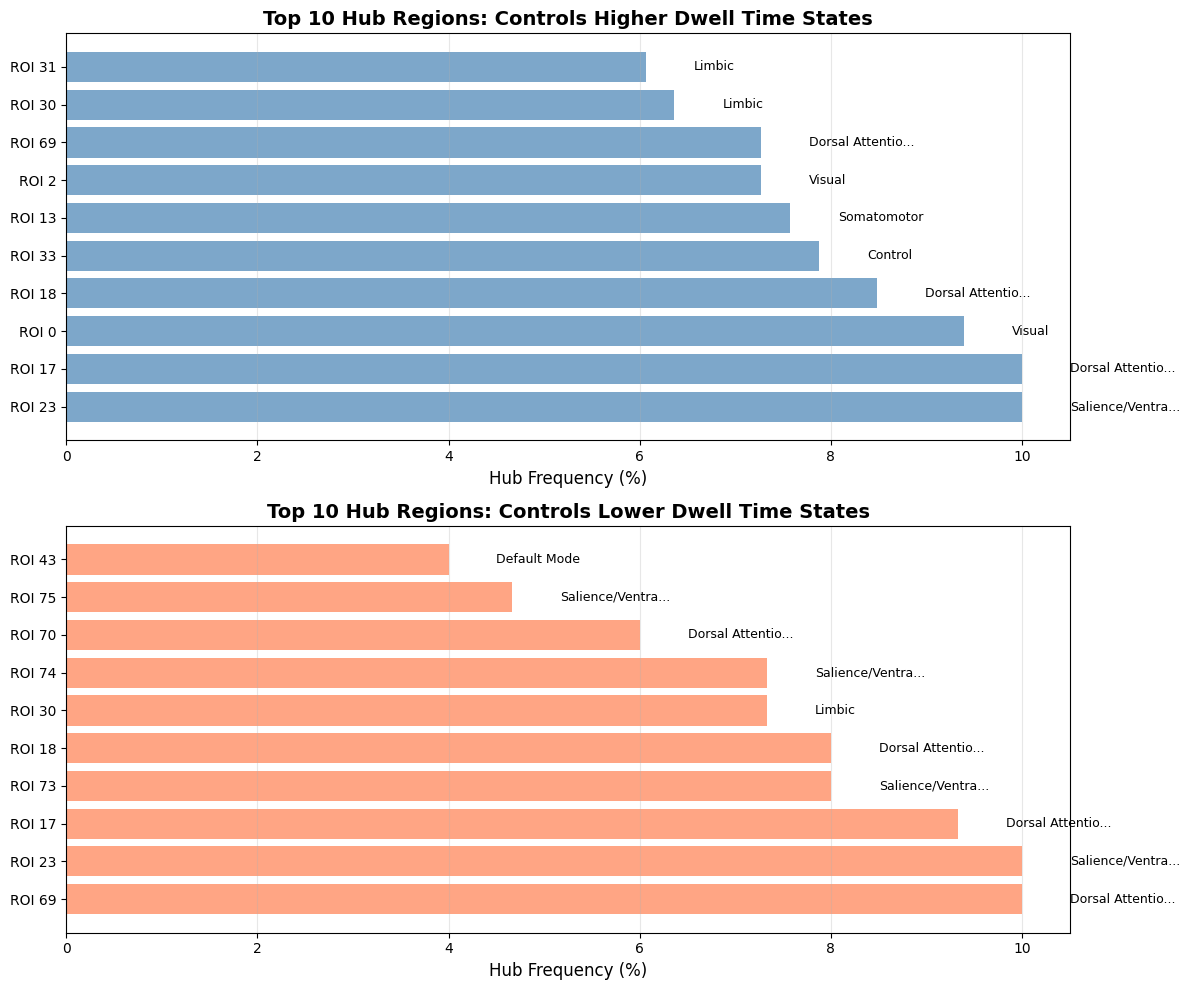

Hub summary plots saved as 'hub_summary_comparison.png'
Top 10 hubs for 'N higher dwell time' saved to 'top_10_hubs_N_higher_dwell_time.csv'
Top 10 hubs for 'N lower dwell time' saved to 'top_10_hubs_N_lower_dwell_time.csv'
Complete hub analysis saved to 'corrected_multi_seed_hub_analysis.csv'


Corrected multi-seed hub analysis complete!
✓ Properly calculated hubness as proportion of strong connections
✓ Identified top 10 most reliable hub regions for each direction
✓ Generated brain surface plots and summary visualizations
✓ Saved detailed results for further analysis


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ENHANCED MULTI-SEED HUB ANALYSIS WITH CORRECTED HUBNESS CALCULATION
==================================================================
This version correctly calculates hubness as the proportion of other regions
that are strongly connected to each ROI, then reports top 10 hubs by proportion.
"""

import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from scipy import stats
from collections import Counter
from sklearn.cluster import KMeans
from statsmodels.stats.multitest import multipletests
from nilearn.plotting import plot_img_on_surf, show
import templateflow.api as tf
import warnings
import matplotlib.pyplot as plt
import os
from scipy.stats import kruskal, shapiro, levene

# ================================================================================================
# CONFIGURATION
# ================================================================================================

BASE_DIR = ""
CONN_DIR = os.path.join(BASE_DIR, "subject_windows_confounds_old_60sec")

# MULTIPLE SEEDS FOR ROBUST RESULTS
SEED_LIST = [100, 200, 300, 400, 500]  # Multiple seeds for K-means initialization

# Analysis parameters
K_RANGE = range(4, 10)  # The range of K values to analyze
P_VALUE_THRESHOLD = 0.05  # Use uncorrected p-value
KMEANS_N_INIT = "auto"
KMEANS_MAX_ITER = 100000
WIN_STEP = 5
TR = 0.8
HUB_THRESHOLD_STD = 2.0  # Number of std deviations for hub threshold

# Statistical test parameters
NORMALITY_ALPHA = 0.05
VARIANCE_ALPHA = 0.05
MIN_SAMPLE_SIZE = 3

# ================================================================================================
# DATA LOADING
# ================================================================================================

print("Loading data...")
list_of_files = os.listdir(CONN_DIR)
print(f"Found {len(list_of_files)} files")

all_data = []
all_labels = []
for file in list_of_files:
    if file.endswith(".npz"):
        data = np.load(os.path.join(CONN_DIR, file))
        
        AP_temp = data["AP"]
        PA_temp = data["PA"]
        label = data["label"]
        
        sub_data = np.concatenate((AP_temp, PA_temp), axis=0)
        
        all_data.append(sub_data)
        all_labels.append(label)

all_data = np.array(all_data)
all_labels = np.array(all_labels)

n_subjects, n_timepoints, n_features = all_data.shape
print(f"Data loaded: {n_subjects} subjects × {n_timepoints} timepoints × {n_features} features")

# ================================================================================================
# ATLAS LOADING
# ================================================================================================

print("Loading atlas information...")
try:
    # Load Schaefer atlas information
    atlas_path = tf.get(
        template='MNI152NLin2009cAsym', atlas='Schaefer2018',
        desc='100Parcels7Networks', extension='.tsv'
    )
    atlas_df = pd.read_csv(atlas_path, sep='\t')
    
    # Load the atlas image file
    atlas_img_path = tf.get(
        template='MNI152NLin2009cAsym', atlas='Schaefer2018',
        desc='100Parcels7Networks', resolution=2, extension='.nii.gz'
    )
    atlas_img = nib.load(str(atlas_img_path))
    
    print("Atlas information loaded successfully.")

except Exception as e:
    print(f"Error loading atlas information: {e}")
    atlas_df = None
    atlas_img = None

# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================

# Dictionary to map network abbreviations to full names
NETWORK_MAP = {
    "Vis": "Visual",
    "SomMot": "Somatomotor",
    "DorsAttn": "Dorsal Attention",
    "SalVentAttn": "Salience/Ventral Attention",
    "Limbic": "Limbic",
    "Cont": "Control",
    "Default": "Default Mode"
}

def get_roi_info_detailed(roi_idx):
    """Get detailed, unabbreviated information about a ROI, including hemisphere."""
    if atlas_df is None or roi_idx >= len(atlas_df):
        return {
            'hemisphere': 'N/A',
            'network_full': 'Unknown',
            'region_full': f'ROI_{roi_idx}',
        }
    
    # Original name from atlas, e.g., '7Networks_LH_Default_pCunPCC_1'
    original_name = atlas_df.loc[roi_idx, 'name']
    
    # Remove the '7Networks_' prefix
    name_parts = original_name.replace('7Networks_', '').split('_')
    
    hemisphere = name_parts[0]
    network_abbr = name_parts[1]
    region_parts = name_parts[2:]
    
    network_full = NETWORK_MAP.get(network_abbr, network_abbr)
    region_full = "_".join(region_parts)

    return {
        'hemisphere': hemisphere,
        'network_full': network_full,
        'region_full': region_full,
    }

def get_group_name(label):
    """Map numeric labels to group names."""
    group_names = {0: 'N', 1: 'A+P-', 2: 'A+P+'}
    return group_names.get(label, f'Group_{label}')

def get_state_connectivity_matrix(cluster_center, n_rois):
    """Convert cluster center vector to connectivity matrix."""
    conn_matrix = np.zeros((n_rois, n_rois))
    idx = 0
    for i in range(n_rois):
        for j in range(i + 1, n_rois):
            conn_matrix[i, j] = conn_matrix[j, i] = cluster_center[idx]
            idx += 1
    return conn_matrix

def test_assumptions_and_choose_test(groups, state_id, k_clusters):
    """Test assumptions and choose appropriate statistical test."""
    test_details = {
        'state': state_id,
        'k': k_clusters,
        'n_groups': len(groups),
        'group_sizes': [len(g) for g in groups],
        'test_used': 'None',
        'reason': 'Not tested'
    }
    
    # Basic checks
    if len(groups) < 2 or any(g.size == 0 for g in groups):
        test_details['reason'] = 'Insufficient groups or empty groups'
        return 'None', 1.0, 0.0, test_details
    
    if np.std(np.concatenate(groups)) <= 1e-10:
        test_details['reason'] = 'No variance in data'
        return 'None', 1.0, 0.0, test_details
    
    # Check sample sizes for normality testing
    if any(len(g) < MIN_SAMPLE_SIZE for g in groups):
        test_details['reason'] = f'Sample size too small (min {MIN_SAMPLE_SIZE})'
        test_details['test_used'] = 'Kruskal-Wallis'
        try:
            f_stat, p_value = kruskal(*groups)
        except:
            return 'None', 1.0, 0.0, test_details
        return 'Kruskal-Wallis', p_value, f_stat, test_details
    
    # Test normality for each group
    normality_pvals = []
    for group in groups:
        try:
            _, p_val = shapiro(group)
            normality_pvals.append(p_val)
        except:
            normality_pvals.append(0.0)
    
    all_normal = all(p > NORMALITY_ALPHA for p in normality_pvals)
    
    if not all_normal:
        test_details['reason'] = 'One or more groups not normally distributed'
        test_details['test_used'] = 'Kruskal-Wallis'
        try:
            f_stat, p_value = kruskal(*groups)
        except:
            return 'None', 1.0, 0.0, test_details
        return 'Kruskal-Wallis', p_value, f_stat, test_details
    
    # Test homogeneity of variance
    try:
        _, variance_p = levene(*groups)
        if variance_p <= VARIANCE_ALPHA:
            test_details['reason'] = 'Unequal variances detected'
            test_details['test_used'] = 'Kruskal-Wallis'
            f_stat, p_value = kruskal(*groups)
            return 'Kruskal-Wallis', p_value, f_stat, test_details
    except:
        test_details['reason'] = 'Could not test variance homogeneity'
        test_details['test_used'] = 'Kruskal-Wallis'
        try:
            f_stat, p_value = kruskal(*groups)
        except:
            return 'None', 1.0, 0.0, test_details
        return 'Kruskal-Wallis', p_value, f_stat, test_details
    
    # All assumptions met - use ANOVA
    test_details['reason'] = 'All parametric assumptions satisfied'
    test_details['test_used'] = 'ANOVA'
    try:
        f_stat, p_value = stats.f_oneway(*groups)
    except:
        return 'None', 1.0, 0.0, test_details
    return 'ANOVA', p_value, f_stat, test_details

# ================================================================================================
# CORRECTED HUB ANALYSIS FUNCTIONS
# ================================================================================================

def analyze_global_state_hubs_multi_seed_corrected():
    """
    CORRECTED MULTI-SEED ANALYSIS: Properly calculate hubness scores
    """
    # Store global hub results across all seeds
    all_global_hub_results = []
    all_statistical_results = []
    
    # Estimate number of ROIs from data shape
    n_connections = all_data.shape[-1]
    n_rois = int((1 + np.sqrt(1 + 8 * n_connections)) / 2)
    print(f"Estimated {n_rois} ROIs from {n_connections} connections.")
    print(f"Using {len(SEED_LIST)} seeds: {SEED_LIST}")
    
    # Loop through all K values
    for K_CLUSTERS in K_RANGE:
        print(f"\n{'='*100}")
        print(f"ANALYZING FOR K = {K_CLUSTERS} ACROSS {len(SEED_LIST)} SEEDS")
        print(f"{'='*100}")
        
        # Store results for this K across all seeds
        k_results_across_seeds = []
        
        # Loop through all seeds
        for seed_idx, SEED in enumerate(SEED_LIST):
            print(f"\n{'-'*60}")
            print(f"SEED {seed_idx + 1}/{len(SEED_LIST)}: {SEED}")
            print(f"{'-'*60}")

            # 1. K-Means Clustering with current seed
            reshaped_data = all_data.reshape(-1, n_features)
            kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=SEED, 
                           n_init=KMEANS_N_INIT, max_iter=KMEANS_MAX_ITER)
            cluster_labels_flat = kmeans.fit_predict(reshaped_data)
            cluster_labels_reshaped = cluster_labels_flat.reshape(n_subjects, n_timepoints)

            # 2. Dwell Time Extraction
            dwell_times = np.array([np.bincount(seq, minlength=K_CLUSTERS) * WIN_STEP * TR 
                                   for seq in cluster_labels_reshaped])

            # 3. Statistical testing to find significant states for this seed
            unique_labels = np.unique(all_labels)
            significant_states = []
            
            for state in range(K_CLUSTERS):
                groups = [dwell_times[all_labels == label, state] for label in unique_labels]
                groups = [g for g in groups if g.size > 0]  # Remove empty groups
                
                if len(groups) < 2:
                    continue
                    
                # Test assumptions and perform appropriate statistical test
                test_type, p_value, f_stat, test_details = test_assumptions_and_choose_test(
                    groups, state, K_CLUSTERS)
                
                # Add seed information to test details
                test_details['seed'] = SEED
                all_statistical_results.append(test_details)
                
                if test_type != 'None' and p_value < P_VALUE_THRESHOLD:
                    significant_states.append(state)
                    print(f"    State {state}: {test_type}, p={p_value:.4f} - SIGNIFICANT")
                elif test_type != 'None':
                    print(f"    State {state}: {test_type}, p={p_value:.4f}")
            
            print(f"    Found {len(significant_states)} significant states for K={K_CLUSTERS}, Seed={SEED}")

            # 4. **CORRECTED** Global hub analysis for each significant state in this seed
            seed_hub_results = []
            for state in significant_states:
                # Determine dwell time direction for this specific state
                mean_dt_N = np.mean(dwell_times[all_labels == 0, state])
                mean_dt_patients = np.mean(dwell_times[all_labels > 0, state])
                
                direction = "N_higher" if mean_dt_N > mean_dt_patients else "N_lower"
                
                print(f"    State {state} ({direction}): N={mean_dt_N:.2f}s, Patients={mean_dt_patients:.2f}s")
                
                # **KEY: Use ALL windows assigned to this state**
                state_matrices = reshaped_data[cluster_labels_flat == state]
                
                if len(state_matrices) == 0:
                    continue

                # Global mean connectivity for this state
                global_mean_vector = np.mean(state_matrices, axis=0)
                global_mean_matrix = get_state_connectivity_matrix(global_mean_vector, n_rois)
                
                # **CORRECTED HUB CALCULATION**
                # Hub identification using global threshold
                threshold = np.median(global_mean_matrix) + HUB_THRESHOLD_STD * np.std(global_mean_matrix)
                global_binary_matrix = (global_mean_matrix > threshold).astype(int)
                np.fill_diagonal(global_binary_matrix, 0)  # Remove self-connections
                
                # **CORRECTED: Hubness = (number of strong connections) / (total possible connections)**
                hubness_scores = np.sum(global_binary_matrix, axis=1) / (n_rois - 1)
                
                # Top 10 hubs for this state
                top_10_indices = np.argsort(hubness_scores)[::-1][:10]
                
                print(f"      Top 5 hubs (corrected calculation):")
                for i, roi_idx in enumerate(top_10_indices[:5]):
                    roi_info = get_roi_info_detailed(roi_idx)
                    score = hubness_scores[roi_idx]
                    n_connections = int(score * (n_rois - 1))  # Convert back to actual number
                    print(f"        {i+1}. ROI {roi_idx} (hubness={score:.3f}, {n_connections}/{n_rois-1} connections): {roi_info['hemisphere']} {roi_info['network_full']}")
                
                # Store hub results for this seed
                for roi_idx in top_10_indices:
                    seed_hub_results.append({
                        'roi_index': roi_idx,
                        'k': K_CLUSTERS,
                        'state': state,
                        'seed': SEED,
                        'direction': direction,
                        'hubness_score': hubness_scores[roi_idx],
                        'n_connections': int(hubness_scores[roi_idx] * (n_rois - 1)),
                        'total_possible_connections': n_rois - 1,
                        'state_id': f"K{K_CLUSTERS}_S{state}_Seed{SEED}",
                        'mean_dt_N': mean_dt_N,
                        'mean_dt_patients': mean_dt_patients
                    })
            
            k_results_across_seeds.extend(seed_hub_results)
        
        # Add all results for this K to the global results
        all_global_hub_results.extend(k_results_across_seeds)
        
        print(f"\nSUMMARY FOR K={K_CLUSTERS}:")
        print(f"  Total hub instances across all seeds: {len(k_results_across_seeds)}")
        if k_results_across_seeds:
            k_df = pd.DataFrame(k_results_across_seeds)
            direction_counts = k_df['direction'].value_counts()
            seed_counts = k_df['seed'].value_counts()
            print(f"  Direction distribution: {dict(direction_counts)}")
            print(f"  Seed distribution: {dict(seed_counts)}")
    
    return all_global_hub_results, all_statistical_results

def report_top_10_hubs_by_proportion(hub_df, title):
    """Report top 10 ROIs based on their hubness proportion across all instances."""
    print(f"\n{'='*120}")
    print(f"TOP 10 HUBS BY HUBNESS PROPORTION: {title}")
    print(f"{'='*120}")
    
    if hub_df.empty:
        print("No hubs found for this direction.")
        return []
    
    # Calculate total possible hub instances for this direction
    total_states = hub_df['state_id'].nunique()
    max_hubs_per_state = 10  # We select top 10 hubs per state
    total_possible_hub_instances = total_states * max_hubs_per_state
    
    print(f"Analysis based on {len(hub_df)} hub instances from {total_states} unique states")
    print(f"Total possible hub instances: {total_possible_hub_instances}")
    
    # **Calculate both frequency proportion AND mean hubness scores**
    roi_counts = Counter(hub_df['roi_index'])
    
    enhanced_hub_results = []
    for roi_idx, frequency in roi_counts.items():
        # Calculate frequency proportion (how often this ROI appears as a hub)
        frequency_proportion = frequency / total_possible_hub_instances
        
        # **Calculate mean hubness score across all appearances**
        roi_data = hub_df[hub_df['roi_index'] == roi_idx]
        mean_hubness_score = roi_data['hubness_score'].mean()
        mean_n_connections = roi_data['n_connections'].mean()
        total_possible_connections = roi_data['total_possible_connections'].iloc[0]  # Should be same for all
        
        # Get additional statistics
        n_states = roi_data['state_id'].nunique()
        n_seeds = roi_data['seed'].nunique()
        
        # Get ROI information
        roi_info = get_roi_info_detailed(roi_idx)
        
        enhanced_hub_results.append({
            'roi_index': roi_idx,
            'frequency': frequency,
            'frequency_proportion': frequency_proportion,
            'mean_hubness_score': mean_hubness_score,
            'mean_n_connections': mean_n_connections,
            'total_possible_connections': total_possible_connections,
            'n_states': n_states,
            'n_seeds': n_seeds,
            **roi_info
        })
    
    # **Sort by frequency proportion (how reliably it appears as a hub)**
    enhanced_hub_results.sort(key=lambda x: x['frequency_proportion'], reverse=True)
    
    # Display top 10 results
    print(f"\nTOP 10 BRAIN REGIONS BY HUBNESS PROPORTION:")
    print(f"{'Rank':<4} {'ROI':<3} {'Prop%':<6} {'MeanHub':<8} {'AvgConn':<7} {'States':<6} {'Seeds':<5} {'Hem':<3} {'Network':<25} {'Region'}")
    print("-" * 120)
    
    top_10_results = []
    for rank, result in enumerate(enhanced_hub_results[:10], 1):
        print(f"{rank:<4} {result['roi_index']:<3} {result['frequency_proportion']*100:<6.2f} "
              f"{result['mean_hubness_score']:<8.3f} {result['mean_n_connections']:<7.1f} "
              f"{result['n_states']:<6} {result['n_seeds']:<5} "
              f"{result['hemisphere']:<3} {result['network_full']:<25} "
              f"{result['region_full']}")
        
        top_10_results.append({
            'rank': rank,
            'roi_index': result['roi_index'],
            'frequency_proportion_percent': result['frequency_proportion'] * 100,
            'mean_hubness_score': result['mean_hubness_score'],
            'mean_n_connections': result['mean_n_connections'],
            'total_possible_connections': result['total_possible_connections'],
            'hemisphere': result['hemisphere'],
            'network': result['network_full'],
            'region': result['region_full'],
            'appears_in_n_states': result['n_states'],
            'appears_in_n_seeds': result['n_seeds']
        })
    
    print(f"\nInterpretation:")
    print(f"- 'Prop%': Percentage of times this ROI appears as a hub across all possible instances")
    print(f"- 'MeanHub': Average proportion of other regions strongly connected to this ROI")
    print(f"- 'AvgConn': Average number of strong connections (out of {enhanced_hub_results[0]['total_possible_connections']} possible)")
    print(f"- 'States': Number of different brain states where this ROI appears as a hub")
    print(f"- 'Seeds': Number of different K-means seeds where this ROI appears as a hub")
    
    return top_10_results

def run_corrected_hub_analysis():
    """Run the corrected multi-seed hub analysis and report top 10 hubs."""
    print("Running CORRECTED multi-seed hub analysis...")
    print(f"Using seeds: {SEED_LIST}")
    
    # Run corrected analysis
    global_hub_results, all_statistical_results = analyze_global_state_hubs_multi_seed_corrected()
    
    if not global_hub_results:
        print("No hub results found across any seed.")
        return None, [], []
    
    # Convert to DataFrame for easier analysis
    df_hubs = pd.DataFrame(global_hub_results)
    
    print(f"\n{'='*120}")
    print("OVERVIEW OF CORRECTED HUB ANALYSIS RESULTS")
    print(f"{'='*120}")
    
    print(f"Total hub instances collected: {len(df_hubs)}")
    print(f"Unique states analyzed: {df_hubs['state_id'].nunique()}")
    print(f"K values: {sorted(df_hubs['k'].unique())}")
    print(f"Seeds: {sorted(df_hubs['seed'].unique())}")
    
    # Show distribution by direction
    direction_counts = df_hubs['direction'].value_counts()
    print(f"\nHub instances by direction:")
    for direction, count in direction_counts.items():
        print(f"  {direction}: {count} instances")
    
    # **Report top 10 hubs for each direction**
    n_higher_top10 = report_top_10_hubs_by_proportion(
        df_hubs[df_hubs['direction'] == 'N_higher'], 
        "States where Controls have Higher Dwell Time"
    )
    
    n_lower_top10 = report_top_10_hubs_by_proportion(
        df_hubs[df_hubs['direction'] == 'N_lower'], 
        "States where Controls have Lower Dwell Time"
    )
    
    # Save results
    if n_higher_top10:
        pd.DataFrame(n_higher_top10).to_csv('top_10_hubs_N_higher_dwell_time.csv', index=False)
        print(f"\nTop 10 hubs for 'N higher dwell time' saved to 'top_10_hubs_N_higher_dwell_time.csv'")
    
    if n_lower_top10:
        pd.DataFrame(n_lower_top10).to_csv('top_10_hubs_N_lower_dwell_time.csv', index=False)
        print(f"Top 10 hubs for 'N lower dwell time' saved to 'top_10_hubs_N_lower_dwell_time.csv'")
    
    # Save comprehensive results
    df_hubs.to_csv('corrected_multi_seed_hub_analysis.csv', index=False)
    print(f"Complete hub analysis saved to 'corrected_multi_seed_hub_analysis.csv'")
    
    return df_hubs, n_higher_top10, n_lower_top10

# ================================================================================================
# VISUALIZATION FUNCTIONS
# ================================================================================================

def create_brain_surface_plots(hub_df, title, color_scheme):
    """Create brain surface plots for hub regions."""
    if hub_df.empty or atlas_img is None:
        print(f"Cannot create brain plots for '{title}' - no data or atlas image available")
        return
    
    print(f"\nGenerating brain surface plots for '{title}'...")
    
    # Calculate hub frequencies
    roi_counts = Counter(hub_df['roi_index'])
    
    # Create statistical map
    stat_data = np.zeros_like(atlas_img.get_fdata())
    
    for roi_idx, frequency in roi_counts.items():
        # Atlas ROI indices are 1-based, so add 1
        roi_mask = atlas_img.get_fdata() == (roi_idx + 1)
        stat_data[roi_mask] = frequency
    
    # Create Nifti image
    hub_stat_img = nib.Nifti1Image(stat_data, atlas_img.affine, atlas_img.header)
    
    # Define views and hemispheres
    views = ["lateral", "medial"]  # "dorsal", "ventral", "anterior", "posterior"
    hemispheres = "both"
    
    try:
        # Create the surface plot
        plot_img_on_surf(
            stat_map=hub_stat_img,
            views=["lateral", "medial"],
            hemispheres=["left", "right"],
            bg_on_data=True,
            # darkness=0.7,
            colorbar=True,
            cmap=color_scheme,
            threshold=1,  # Only show ROIs that appear at least once
            output_file=f'{title.replace(" ", "_").replace("/", "_")}_hub_frequency_map.png',
            symmetric_cbar=False,
            # title=f'Hub Frequency: {title}'
        )
        print(f"Brain surface plot saved as '{title.replace(' ', '_').replace('/', '_')}_hub_frequency_map.png'")
        
    except Exception as e:
        print(f"Warning: Could not generate brain surface plots for '{title}'. Error: {e}")

def create_hub_summary_plots(n_higher_top10, n_lower_top10):
    """Create summary bar plots of top hub regions."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: N Higher Dwell Time States
    if n_higher_top10:
        rois = [f"ROI {result['roi_index']}" for result in n_higher_top10]
        proportions = [result['frequency_proportion_percent'] for result in n_higher_top10]
        networks = [result['network'] for result in n_higher_top10]
        
        bars1 = ax1.barh(range(len(rois)), proportions, color='steelblue', alpha=0.7)
        ax1.set_yticks(range(len(rois)))
        ax1.set_yticklabels(rois)
        ax1.set_xlabel('Hub Frequency (%)', fontsize=12)
        ax1.set_title('Top 10 Hub Regions: Controls Higher Dwell Time States', fontsize=14, fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)
        
        # Add network labels
        for i, (bar, network) in enumerate(zip(bars1, networks)):
            ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                    network[:15] + ('...' if len(network) > 15 else ''), 
                    va='center', fontsize=9)
    
    # Plot 2: N Lower Dwell Time States
    if n_lower_top10:
        rois = [f"ROI {result['roi_index']}" for result in n_lower_top10]
        proportions = [result['frequency_proportion_percent'] for result in n_lower_top10]
        networks = [result['network'] for result in n_lower_top10]
        
        bars2 = ax2.barh(range(len(rois)), proportions, color='coral', alpha=0.7)
        ax2.set_yticks(range(len(rois)))
        ax2.set_yticklabels(rois)
        ax2.set_xlabel('Hub Frequency (%)', fontsize=12)
        ax2.set_title('Top 10 Hub Regions: Controls Lower Dwell Time States', fontsize=14, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        # Add network labels
        for i, (bar, network) in enumerate(zip(bars2, networks)):
            ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                    network[:15] + ('...' if len(network) > 15 else ''), 
                    va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('hub_summary_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Hub summary plots saved as 'hub_summary_comparison.png'")

# ================================================================================================
# UPDATED MAIN EXECUTION WITH PLOTTING
# ================================================================================================

def run_corrected_hub_analysis_with_plots():
    """Run the corrected multi-seed hub analysis with visualization."""
    print("Running CORRECTED multi-seed hub analysis with visualization...")
    print(f"Using seeds: {SEED_LIST}")
    
    # Run corrected analysis
    global_hub_results, all_statistical_results = analyze_global_state_hubs_multi_seed_corrected()
    
    if not global_hub_results:
        print("No hub results found across any seed.")
        return None, [], []
    
    # Convert to DataFrame for easier analysis
    df_hubs = pd.DataFrame(global_hub_results)
    
    print(f"\n{'='*120}")
    print("OVERVIEW OF CORRECTED HUB ANALYSIS RESULTS")
    print(f"{'='*120}")
    
    print(f"Total hub instances collected: {len(df_hubs)}")
    print(f"Unique states analyzed: {df_hubs['state_id'].nunique()}")
    print(f"K values: {sorted(df_hubs['k'].unique())}")
    print(f"Seeds: {sorted(df_hubs['seed'].unique())}")
    
    # Show distribution by direction
    direction_counts = df_hubs['direction'].value_counts()
    print(f"\nHub instances by direction:")
    for direction, count in direction_counts.items():
        print(f"  {direction}: {count} instances")
    
    # **Report top 10 hubs for each direction**
    n_higher_top10 = report_top_10_hubs_by_proportion(
        df_hubs[df_hubs['direction'] == 'N_higher'], 
        "States where Controls have Higher Dwell Time"
    )
    
    n_lower_top10 = report_top_10_hubs_by_proportion(
        df_hubs[df_hubs['direction'] == 'N_lower'], 
        "States where Controls have Lower Dwell Time"
    )
    
    # **CREATE VISUALIZATIONS**
    print(f"\n{'='*120}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*120}")
    
    # Create brain surface plots
    create_brain_surface_plots(
        df_hubs[df_hubs['direction'] == 'N_higher'], 
        "Controls Higher Dwell Time States", 
        "Blues"
    )
    
    create_brain_surface_plots(
        df_hubs[df_hubs['direction'] == 'N_lower'], 
        "Controls Lower Dwell Time States", 
        "Reds"
    )
    
    # Create summary bar plots
    create_hub_summary_plots(n_higher_top10, n_lower_top10)
    
    # Save results
    if n_higher_top10:
        pd.DataFrame(n_higher_top10).to_csv('top_10_hubs_N_higher_dwell_time.csv', index=False)
        print(f"Top 10 hubs for 'N higher dwell time' saved to 'top_10_hubs_N_higher_dwell_time.csv'")
    
    if n_lower_top10:
        pd.DataFrame(n_lower_top10).to_csv('top_10_hubs_N_lower_dwell_time.csv', index=False)
        print(f"Top 10 hubs for 'N lower dwell time' saved to 'top_10_hubs_N_lower_dwell_time.csv'")
    
    # Save comprehensive results
    df_hubs.to_csv('corrected_multi_seed_hub_analysis.csv', index=False)
    print(f"Complete hub analysis saved to 'corrected_multi_seed_hub_analysis.csv'")
    
    return df_hubs, n_higher_top10, n_lower_top10


# ================================================================================================

df_hubs, n_higher_top10, n_lower_top10 = run_corrected_hub_analysis_with_plots()

print("\n\nCorrected multi-seed hub analysis complete!")
print("✓ Properly calculated hubness as proportion of strong connections")
print("✓ Identified top 10 most reliable hub regions for each direction")
print("✓ Generated brain surface plots and summary visualizations")
print("✓ Saved detailed results for further analysis")

In [5]:
import pandas as pd
from scipy import stats
from collections import Counter
import numpy as np

# --- Statistical Comparison of Hub Distributions ---
print(f"\n{'='*100}")
print("STATISTICAL COMPARISON OF HUB DISTRIBUTIONS")
print(f"{'='*100}")

# Check if hub results exist - use .empty for DataFrames
if df_hubs.empty:
    print("No hub results found. Please run the hub analysis first.")
else:
    # df_hubs is already a DataFrame, no need to convert again
    # If it was a list, you would convert it here
    
    # 1. Filter hubs by direction and get ROI counts
    hubs_N_higher = df_hubs[df_hubs['direction'] == 'N_higher']
    hubs_N_lower = df_hubs[df_hubs['direction'] == 'N_lower']
    
    counts_N_higher = Counter(hubs_N_higher['roi_index'])
    counts_N_lower = Counter(hubs_N_lower['roi_index'])
    
    print(f"Found {len(hubs_N_higher)} hub instances in 'N_higher' direction")
    print(f"Found {len(hubs_N_lower)} hub instances in 'N_lower' direction")
    
    # 2. Get the set of all unique ROIs that appeared as a hub in either condition
    all_observed_rois = sorted(list(set(counts_N_higher.keys()) | set(counts_N_lower.keys())))

    if not all_observed_rois:
        print("No hubs found in either category. Cannot perform statistical comparison.")
    else:
        print(f"Total unique ROIs that appear as hubs: {len(all_observed_rois)}")
        
        # 3. Create a contingency table (DataFrame) for the Chi-Squared test
        contingency_data = {
            'N_higher_counts': [counts_N_higher.get(roi, 0) for roi in all_observed_rois],
            'N_lower_counts': [counts_N_lower.get(roi, 0) for roi in all_observed_rois]
        }
        contingency_table = pd.DataFrame(contingency_data, index=all_observed_rois)

        # Filter out rows where both counts are zero
        contingency_table = contingency_table.loc[(contingency_table.sum(axis=1) > 0)]

        print(f"\nContingency Table of Hub Frequencies ({len(contingency_table)} ROIs):")
        print(contingency_table.head(20))
        if len(contingency_table) > 20:
            print(f"... and {len(contingency_table) - 20} more ROIs")
            
        # 4. Perform the Chi-Squared test of independence (Omnibus Test)
        try:
            chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

            print("\n--- Chi-Squared Test Results ---")
            print(f"Chi-Squared Statistic: {chi2:.4f}")
            print(f"P-value: {p:.4f}")
            print(f"Degrees of Freedom: {dof}")

            if p < 0.05:
                print("\nConclusion: The p-value is less than 0.05.")
                print("We can conclude that there is a statistically significant difference in the distribution of hub regions between the two conditions.")

                # 5. Post-hoc analysis using standardized residuals
                print("\n--- Post-Hoc Analysis (Standardized Residuals) ---")
                print("This analysis identifies which specific ROIs contribute most to the overall significant difference.")
                print("A standardized residual > 1.96 or < -1.96 is typically considered significant (p < 0.05).\n")

                # Calculate standardized residuals
                residuals = (contingency_table - expected) / np.sqrt(expected)
                
                # Create a results table with ROI info
                posthoc_df = contingency_table.copy()
                posthoc_df['std_residual'] = residuals['N_higher_counts']
                
                # Add detailed ROI info
                roi_info_list = [get_roi_info_detailed(roi_idx) for roi_idx in posthoc_df.index]
                posthoc_df['network'] = [info['network_full'] for info in roi_info_list]
                posthoc_df['region'] = [info['region_full'] for info in roi_info_list]
                posthoc_df['hemisphere'] = [info['hemisphere'] for info in roi_info_list]
                
                # Identify significant contributors
                significant_contributors = posthoc_df[np.abs(posthoc_df['std_residual']) > 1.96].sort_values(by='std_residual', ascending=False)

                if not significant_contributors.empty:
                    print("ROIs with significantly different proportions between conditions:")
                    display_cols = ['hemisphere', 'network', 'region', 'N_higher_counts', 'N_lower_counts', 'std_residual']
                    print(significant_contributors[display_cols].to_string())
                    print("\nInterpretation:")
                    print("- Positive residual: ROI is a significantly more frequent hub in the 'N_higher' condition.")
                    print("- Negative residual: ROI is a significantly more frequent hub in the 'N_lower' condition.")
                    
                    # Save significant contributors
                    significant_contributors.to_csv('significant_hub_differences.csv')
                    print(f"\nSignificant contributors saved to 'significant_hub_differences.csv'")
                    
                else:
                    print("No individual ROI found to be a significant contributor at the p < 0.05 level after analyzing residuals.")

            else:
                print("\nConclusion: The p-value is not less than 0.05.")
                print("We cannot conclude that there is a significant difference in the distribution of hub regions between the two conditions.")
                
            # Save contingency table regardless of significance
            contingency_table_with_info = contingency_table.copy()
            roi_info_list = [get_roi_info_detailed(roi_idx) for roi_idx in contingency_table_with_info.index]
            contingency_table_with_info['hemisphere'] = [info['hemisphere'] for info in roi_info_list]
            contingency_table_with_info['network'] = [info['network_full'] for info in roi_info_list]
            contingency_table_with_info['region'] = [info['region_full'] for info in roi_info_list]
            
            contingency_table_with_info.to_csv('hub_contingency_table.csv')
            print(f"\nFull contingency table with ROI details saved to 'hub_contingency_table.csv'")

        except ValueError as e:
            print(f"\nCould not perform Chi-Squared test. Error: {e}")
            print("This can happen if the contingency table is empty or does not have enough data.")


STATISTICAL COMPARISON OF HUB DISTRIBUTIONS
Found 330 hub instances in 'N_higher' direction
Found 150 hub instances in 'N_lower' direction
Total unique ROIs that appear as hubs: 35

Contingency Table of Hub Frequencies (35 ROIs):
    N_higher_counts  N_lower_counts
0                31               3
1                 2               0
2                24               4
11                1               0
13               25               1
15               18               5
16                7               3
17               33              14
18               28              12
20                0               1
22                9               0
23               33              15
28                0               2
30               21              11
31               20               3
33               26               0
35                2               0
36                2               1
37               10               0
42                1               0
... and 15 mo

In [10]:
import pandas as pd
import numpy as np
import os
from scipy.stats import t
from statsmodels.stats.multitest import multipletests

# --- Configuration ---
BASE_RESULTS_DIR = r'/data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results'
ALPHA = 0.05 # Significance level for FDR

TASKS = [
    {
        "task_name": "N vs. AP-",
        "file_pattern": "results_N_vs_AP-_weighted_adaptive",
        "file_prefix": "N_vs_AP-",  # Fixed: underscore instead of hyphen
        "dir1_label": "N > AP-",
        "dir2_label": "AP- > N",
        "dir1_map_cls": "cls0>cls1", # N(0) > AP-(1)
        "dir2_map_cls": "cls1>cls0"  # AP-(1) > N(0)
    },
    {
        "task_name": "N vs. AP+",
        "file_pattern": "results_N_vs_AP+_weighted_adaptive",
        "file_prefix": "N_vs_AP+",  # Fixed: underscore instead of hyphen
        "dir1_label": "N > AP+",
        "dir2_label": "AP+ > N",
        "dir1_map_cls": "cls0>cls1", # N(0) > AP+(1)
        "dir2_map_cls": "cls1>cls0"  # AP+(1) > N(0)
    },
    {
        "task_name": "AP- vs. AP+",
        "file_pattern": "results_AP-_vs_AP+_weighted_adaptive",
        "file_prefix": "AP-_vs_AP+",  # This one matches
        "dir1_label": "AP- > AP+",
        "dir2_label": "AP+ > AP-",
        "dir1_map_cls": "cls0>cls1", # AP-(0) > AP+(1)
        "dir2_map_cls": "cls1>cls0"  # AP+(1) > AP-(0)
    },
    {
        "task_name": "N vs. Patients (Combined)",
        "file_pattern": "results_N_vs_APcombined_weighted_adaptive",
        "file_prefix": "N_vs_APcombined",  # Fixed: underscore instead of hyphen
        "dir1_label": "N > Patients",
        "dir2_label": "Patients > N",
        "dir1_map_cls": "cls0>cls1", # N(0) > Patients(1)
        "dir2_map_cls": "cls1>cls0"  # Patients(1) > N(0)
    }
]

# --- Main Processing Loop ---
summary_data = []
tests_to_correct = [] # Store data for multiple comparison correction
print("Generating overall summary table across all tasks...")

for i, task in enumerate(TASKS):
    # Use the correct file prefix for file names
    file_prefix = task['file_prefix']
    
    # Define primary and fallback file paths with correct naming
    primary_file = os.path.join(BASE_RESULTS_DIR, task['file_pattern'], f"{file_prefix}_direction_wrt_N_overall.csv")
    fallback_file = os.path.join(BASE_RESULTS_DIR, task['file_pattern'], f"{file_prefix}_direction_cls1_vs_cls0_overall.csv")
    
    print(f"  - Looking for: {primary_file}")
    print(f"  - Fallback: {fallback_file}")
    
    df = None
    is_cls_file = False
    try:
        df = pd.read_csv(primary_file)
        print(f"  - Loaded primary file for '{task['task_name']}'")
    except FileNotFoundError:
        try:
            df = pd.read_csv(fallback_file)
            is_cls_file = True
            print(f"  - Primary file not found for '{task['task_name']}'. Loaded fallback 'cls' file.")
        except FileNotFoundError:
            print(f"  - WARNING: Could not find any results file for task '{task['task_name']}'.")
            summary_data.append({"Task": task['task_name']})
            continue

    row_data = {"Task": task['task_name']}

    # Define direction selectors based on which file was loaded
    if is_cls_file:
        dir1_selector = df['direction'] == task['dir1_map_cls']
        dir2_selector = df['direction'] == task['dir2_map_cls']
    else: # It's a 'wrt_N' file
        dir1_selector = df['direction'] == 'N>Other'
        dir2_selector = df['direction'] == 'Other>N'

    # --- Process Direction 1 ---
    dir1_data = df[dir1_selector]
    row_data['Direction 1'] = task['dir1_label']
    if not dir1_data.empty:
        mean_coef = dir1_data['coef_per_16s_mean'].iloc[0]
        std_coef = dir1_data['coef_per_16s_std'].iloc[0]
        count = int(dir1_data['count'].iloc[0])
        
        # Calculate odds ratio and its standard deviation from coefficient
        mean_or = np.exp(mean_coef)
        std_or = mean_or * std_coef # Delta method approximation
        
        # Perform one-sample t-test
        if std_coef > 0 and count > 1:
            t_stat = mean_coef / std_coef # Assuming std_coef is the standard error
            dof = count - 1
            p_value = t.sf(np.abs(t_stat), dof) * 2 # Two-tailed p-value
        else:
            p_value = 1.0 # Not enough data to perform test
            
        tests_to_correct.append({'index': i, 'direction': 1, 'p_value': p_value})
        
        row_data.update({
            'Count 1': count,
            'Coef (SD) 1': f"{mean_coef:.3f} ({std_coef:.3f})",
            'OR (SD) 1': f"{mean_or:.3f} ({std_or:.3f})"
        })
    else:
        row_data.update({'Count 1': 0, 'Coef (SD) 1': 'N/A', 'OR (SD) 1': 'N/A'})

    # --- Process Direction 2 ---
    dir2_data = df[dir2_selector]
    row_data['Direction 2'] = task['dir2_label']
    if not dir2_data.empty:
        mean_coef = dir2_data['coef_per_16s_mean'].iloc[0]
        std_coef = dir2_data['coef_per_16s_std'].iloc[0]
        count = int(dir2_data['count'].iloc[0])

        # Calculate odds ratio and its standard deviation from coefficient
        mean_or = np.exp(mean_coef)
        std_or = mean_or * std_coef # Delta method approximation

        # Perform one-sample t-test
        if std_coef > 0 and count > 1:
            t_stat = mean_coef / std_coef # Assuming std_coef is the standard error
            dof = count - 1
            p_value = t.sf(np.abs(t_stat), dof) * 2 # Two-tailed p-value
        else:
            p_value = 1.0 # Not enough data to perform test

        tests_to_correct.append({'index': i, 'direction': 2, 'p_value': p_value})
        
        row_data.update({
            'Count 2': count,
            'Coef (SD) 2': f"{mean_coef:.3f} ({std_coef:.3f})",
            'OR (SD) 2': f"{mean_or:.3f} ({std_or:.3f})"
        })
    else:
        row_data.update({'Count 2': 0, 'Coef (SD) 2': 'N/A', 'OR (SD) 2': 'N/A'})
        
    summary_data.append(row_data)

# --- Perform FDR Correction ---
if tests_to_correct:
    p_values = [test['p_value'] for test in tests_to_correct]
    is_significant_fdr, p_corrected, _, _ = multipletests(p_values, alpha=ALPHA, method='fdr_bh')
    
    # Map corrected p-values back to the summary_data
    test_idx = 0
    for i in range(len(summary_data)):
        # Check if a test was performed for dir 1 of this task
        if 'Coef (SD) 1' in summary_data[i] and summary_data[i]['Coef (SD) 1'] != 'N/A':
            if test_idx < len(p_corrected):
                summary_data[i]['p (FDR) 1'] = f"{p_corrected[test_idx]:.3f}"
                summary_data[i]['Significant (FDR) 1'] = 'Yes' if is_significant_fdr[test_idx] else 'No'
                test_idx += 1
        else:
            summary_data[i]['p (FDR) 1'] = 'N/A'
            summary_data[i]['Significant (FDR) 1'] = 'N/A'
            
        # Check if a test was performed for dir 2 of this task
        if 'Coef (SD) 2' in summary_data[i] and summary_data[i]['Coef (SD) 2'] != 'N/A':
            if test_idx < len(p_corrected):
                summary_data[i]['p (FDR) 2'] = f"{p_corrected[test_idx]:.3f}"
                summary_data[i]['Significant (FDR) 2'] = 'Yes' if is_significant_fdr[test_idx] else 'No'
                test_idx += 1
        else:
            summary_data[i]['p (FDR) 2'] = 'N/A'
            summary_data[i]['Significant (FDR) 2'] = 'N/A'

# --- Create and Display Final Tables ---
if summary_data:
    full_df = pd.DataFrame(summary_data)

    # --- Table 1 ---
    cols1 = {
        'Task': 'Task', 'Direction 1': 'Direction', 'Count 1': 'Count', 
        'Coef (SD) 1': 'Coef (SD)', 'OR (SD) 1': 'OR (SD)',
        'p (FDR) 1': 'p (FDR)', 'Significant (FDR) 1': 'Significant (FDR)'
    }
    for col in cols1.keys():
        if col not in full_df.columns:
            full_df[col] = 'N/A'
    table1_df = full_df[list(cols1.keys())].rename(columns=cols1).set_index('Task')
    
    print("\n" + "="*100)
    print("Summary Table: Direction 1")
    print("="*100)
    print(table1_df.to_string())
    print("="*100)

    # --- Table 2 ---
    cols2 = {
        'Task': 'Task', 'Direction 2': 'Direction', 'Count 2': 'Count', 
        'Coef (SD) 2': 'Coef (SD)', 'OR (SD) 2': 'OR (SD)',
        'p (FDR) 2': 'p (FDR)', 'Significant (FDR) 2': 'Significant (FDR)'
    }
    for col in cols2.keys():
        if col not in full_df.columns:
            full_df[col] = 'N/A'
    table2_df = full_df[list(cols2.keys())].rename(columns=cols2).set_index('Task')

    print("\n" + "="*100)
    print("Summary Table: Direction 2")
    print("="*100)
    print(table2_df.to_string())
    print("="*100)
    
    # Save the complete results
    full_df.to_csv('summary_table_all_tasks.csv', index=False)
    print(f"\nComplete summary table saved to 'summary_table_all_tasks.csv'")

else:
    print("\nNo data was processed. Please check the file paths and task configurations.")

Generating overall summary table across all tasks...
  - Looking for: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results/results_N_vs_AP-_weighted_adaptive/N_vs_AP-_direction_wrt_N_overall.csv
  - Fallback: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results/results_N_vs_AP-_weighted_adaptive/N_vs_AP-_direction_cls1_vs_cls0_overall.csv
  - Loaded primary file for 'N vs. AP-'
  - Looking for: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results/results_N_vs_AP+_weighted_adaptive/N_vs_AP+_direction_wrt_N_overall.csv
  - Fallback: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results/results_N_vs_AP+_weighted_adaptive/N_vs_AP+_direction_cls1_vs_cls0_overall.csv
  - Loaded primary file for 'N vs. AP+'
  - Looking for: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results/results_AP-_vs_AP+_weighted_adaptive/AP-_vs_AP+_direction_wrt_N_overall.csv
  - Fallback: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/final_results/results_AP-_vs_AP+_weighted_adaptive/AP-_vs_AP+_

In [11]:
def check_actual_roi_names():
    """Check the actual ROI names from the atlas to see what 'Post' refers to"""
    if atlas_df is not None:
        print("Checking actual ROI names from Schaefer atlas...")
        
        # Look specifically at ROIs 17, 18, and 69 that appear in your hub results
        target_rois = [17, 18, 69]
        
        for roi_idx in target_rois:
            if roi_idx < len(atlas_df):
                original_name = atlas_df.loc[roi_idx, 'name']
                print(f"ROI {roi_idx}: {original_name}")
                
                # Parse the name
                roi_info = get_roi_info_detailed(roi_idx)
                print(f"  Parsed - Hemisphere: {roi_info['hemisphere']}")
                print(f"  Parsed - Network: {roi_info['network_full']}")
                print(f"  Parsed - Region: {roi_info['region_full']}")
                print()
        
        # Also check a few more ROIs to see the pattern
        print("Sample of other ROI names:")
        for i in range(min(20, len(atlas_df))):
            original_name = atlas_df.loc[i, 'name']
            print(f"ROI {i}: {original_name}")
    else:
        print("Atlas data not available")

# Run the check
check_actual_roi_names()

Checking actual ROI names from Schaefer atlas...
ROI 17: 7Networks_LH_DorsAttn_Post_3
  Parsed - Hemisphere: LH
  Parsed - Network: Dorsal Attention
  Parsed - Region: Post_3

ROI 18: 7Networks_LH_DorsAttn_Post_4
  Parsed - Hemisphere: LH
  Parsed - Network: Dorsal Attention
  Parsed - Region: Post_4

ROI 69: 7Networks_RH_DorsAttn_Post_4
  Parsed - Hemisphere: RH
  Parsed - Network: Dorsal Attention
  Parsed - Region: Post_4

Sample of other ROI names:
ROI 0: 7Networks_LH_Vis_1
ROI 1: 7Networks_LH_Vis_2
ROI 2: 7Networks_LH_Vis_3
ROI 3: 7Networks_LH_Vis_4
ROI 4: 7Networks_LH_Vis_5
ROI 5: 7Networks_LH_Vis_6
ROI 6: 7Networks_LH_Vis_7
ROI 7: 7Networks_LH_Vis_8
ROI 8: 7Networks_LH_Vis_9
ROI 9: 7Networks_LH_SomMot_1
ROI 10: 7Networks_LH_SomMot_2
ROI 11: 7Networks_LH_SomMot_3
ROI 12: 7Networks_LH_SomMot_4
ROI 13: 7Networks_LH_SomMot_5
ROI 14: 7Networks_LH_SomMot_6
ROI 15: 7Networks_LH_DorsAttn_Post_1
ROI 16: 7Networks_LH_DorsAttn_Post_2
ROI 17: 7Networks_LH_DorsAttn_Post_3
ROI 18: 7Networks_L

In [1]:
import pandas as pd
import numpy as np
import os
from scipy.stats import t
from statsmodels.stats.multitest import multipletests

# --- Configuration ---
BASE_RESULTS_DIR = r'/data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/'
ALPHA = 0.05

TASKS = [
    {
        "task_name": "N vs. AP-",
        "file_pattern": "results_N_vs_AP-_weighted_adaptive",
        "file_prefix": "N_vs_AP-",
        "dir1_label": "N > AP-",
        "dir2_label": "AP- > N",
        "dir1_map_cls": "cls0>cls1",
        "dir2_map_cls": "cls1>cls0"
    },
    {
        "task_name": "N vs. AP+",
        "file_pattern": "results_N_vs_AP+_weighted_adaptive",
        "file_prefix": "N_vs_AP+",
        "dir1_label": "N > AP+",
        "dir2_label": "AP+ > N",
        "dir1_map_cls": "cls0>cls1",
        "dir2_map_cls": "cls1>cls0"
    },
    {
        "task_name": "AP- vs. AP+",
        "file_pattern": "results_AP-_vs_AP+_weighted_adaptive",
        "file_prefix": "AP-_vs_AP+",
        "dir1_label": "AP- > AP+",
        "dir2_label": "AP+ > AP-",
        "dir1_map_cls": "cls0>cls1",
        "dir2_map_cls": "cls1>cls0"
    },
    {
        "task_name": "N vs. Patients (Combined)",
        "file_pattern": "results_N_vs_APcombined_weighted_adaptive",
        "file_prefix": "N_vs_APcombined",
        "dir1_label": "N > Patients",
        "dir2_label": "Patients > N",
        "dir1_map_cls": "cls0>cls1",
        "dir2_map_cls": "cls1>cls0"
    }
]

def compute_stats_using_se(mean_coef: float, std_coef_as_se: float, count: int, alpha: float = ALPHA):
    """
    Compute statistics treating std_coef as standard error (your original approach)
    """
    # FIXED: Treat std_coef as standard error, not standard deviation
    se = std_coef_as_se  # std_coef is already the standard error
    
    if se <= 0 or count <= 1:
        return {
            't_stat': np.nan,
            'p_value': 1.0,
            'or_mean': np.exp(mean_coef),
            'or_se': np.nan,
            'or_ci_low': np.nan,
            'or_ci_high': np.nan
        }
    
    # Calculate t-statistic and p-value
    t_stat = mean_coef / se
    dof = count - 1
    p_value = t.sf(np.abs(t_stat), dof) * 2  # Two-tailed
    
    # Odds ratio calculations
    or_mean = np.exp(mean_coef)
    or_se = or_mean * se  # Delta method
    
    # Confidence intervals
    t_crit = t.ppf(1.0 - alpha / 2.0, dof)
    or_ci_low = np.exp(mean_coef - t_crit * se)
    or_ci_high = np.exp(mean_coef + t_crit * se)
    
    return {
        't_stat': t_stat,
        'p_value': p_value,
        'or_mean': or_mean,
        'or_se': or_se,
        'or_ci_low': or_ci_low,
        'or_ci_high': or_ci_high
    }

# --- Main Processing Loop ---
summary_data = []
tests_to_correct = []
print("Generating overall summary table across all tasks...")

for i, task in enumerate(TASKS):
    file_prefix = task['file_prefix']
    
    primary_file = os.path.join(BASE_RESULTS_DIR, task['file_pattern'], f"{file_prefix}_direction_wrt_N_overall.csv")
    fallback_file = os.path.join(BASE_RESULTS_DIR, task['file_pattern'], f"{file_prefix}_direction_cls1_vs_cls0_overall.csv")
    
    print(f"  - Looking for: {primary_file}")
    print(f"  - Fallback: {fallback_file}")
    
    df = None
    is_cls_file = False
    try:
        df = pd.read_csv(primary_file)
        print(f"  - Loaded primary file for '{task['task_name']}'")
    except FileNotFoundError:
        try:
            df = pd.read_csv(fallback_file)
            is_cls_file = True
            print(f"  - Primary file not found for '{task['task_name']}'. Loaded fallback 'cls' file.")
        except FileNotFoundError:
            print(f"  - WARNING: Could not find any results file for task '{task['task_name']}'.")
            summary_data.append({"Task": task['task_name']})
            continue

    row_data = {"Task": task['task_name']}

    # Define direction selectors
    if is_cls_file:
        dir1_selector = df['direction'] == task['dir1_map_cls']
        dir2_selector = df['direction'] == task['dir2_map_cls']
    else:
        dir1_selector = df['direction'] == 'N>Other'
        dir2_selector = df['direction'] == 'Other>N'

    # --- Process Both Directions ---
    for direction_num, (selector, label) in enumerate([
        (dir1_selector, task['dir1_label']),
        (dir2_selector, task['dir2_label'])
    ], start=1):
        
        dir_data = df[selector]
        row_data[f'Direction {direction_num}'] = label
        
        if not dir_data.empty:
            mean_coef = dir_data['coef_per_16s_mean'].iloc[0]
            std_coef = dir_data['coef_per_16s_std'].iloc[0]
            count = int(dir_data['count'].iloc[0])
            
            # FIXED: Use the corrected statistical calculation
            stats = compute_stats_using_se(mean_coef, std_coef, count, alpha=ALPHA)
            
            # Store for multiple comparison correction
            tests_to_correct.append({
                'index': i, 
                'direction': direction_num, 
                'p_value': stats['p_value']
            })
            
            row_data.update({
                f'Count {direction_num}': count,
                f'Coef (SE) {direction_num}': f"{mean_coef:.3f} ({std_coef:.3f})",
                f'OR (SE) {direction_num}': f"{stats['or_mean']:.3f} ({stats['or_se']:.3f})",
                f't_stat {direction_num}': f"{stats['t_stat']:.3f}",
                f'Raw_p {direction_num}': f"{stats['p_value']:.6f}"
            })
        else:
            row_data.update({
                f'Count {direction_num}': 0, 
                f'Coef (SE) {direction_num}': 'N/A', 
                f'OR (SE) {direction_num}': 'N/A',
                f't_stat {direction_num}': 'N/A',
                f'Raw_p {direction_num}': 'N/A'
            })
        
    summary_data.append(row_data)

# --- Perform FDR Correction ---
if tests_to_correct:
    p_values = [test['p_value'] for test in tests_to_correct]
    is_significant_fdr, p_corrected, _, _ = multipletests(p_values, alpha=ALPHA, method='fdr_bh')
    
    # Map corrected p-values back
    test_idx = 0
    for i in range(len(summary_data)):
        for direction_num in [1, 2]:
            if f'Raw_p {direction_num}' in summary_data[i] and summary_data[i][f'Raw_p {direction_num}'] != 'N/A':
                if test_idx < len(p_corrected):
                    summary_data[i][f'p (FDR) {direction_num}'] = f"{p_corrected[test_idx]:.6f}"
                    summary_data[i][f'Significant (FDR) {direction_num}'] = 'Yes' if is_significant_fdr[test_idx] else 'No'
                    test_idx += 1
            else:
                summary_data[i][f'p (FDR) {direction_num}'] = 'N/A'
                summary_data[i][f'Significant (FDR) {direction_num}'] = 'N/A'

# --- Display Results ---
if summary_data:
    full_df = pd.DataFrame(summary_data)
    
    # Show diagnostic information
    print(f"\n{'='*80}")
    print("DIAGNOSTIC: Raw vs Corrected P-values")
    print(f"{'='*80}")
    
    for _, row in full_df.iterrows():
        task = row['Task']
        for direction_num in [1, 2]:
            raw_p = row.get(f'Raw_p {direction_num}', 'N/A')
            fdr_p = row.get(f'p (FDR) {direction_num}', 'N/A')
            if raw_p != 'N/A' and fdr_p != 'N/A':
                print(f"{task} Dir{direction_num}: Raw p={raw_p}, FDR p={fdr_p}")
    
    # Create formatted tables
    for direction_num in [1, 2]:
        cols = {
            'Task': 'Task', 
            f'Direction {direction_num}': 'Direction', 
            f'Count {direction_num}': 'Count', 
            f'Coef (SE) {direction_num}': 'Coef (SE)', 
            f'OR (SE) {direction_num}': 'OR (SE)',
            f'Raw_p {direction_num}': 'Raw p-value',
            f'p (FDR) {direction_num}': 'p (FDR)', 
            f'Significant (FDR) {direction_num}': 'Significant'
        }
        
        table_df = full_df[list(cols.keys())].rename(columns=cols).set_index('Task')
        
        print(f"\n{'='*120}")
        print(f"Summary Table: Direction {direction_num}")
        print(f"{'='*120}")
        print(table_df.to_string())
    
    # Save results
    full_df.to_csv('summary_table_all_tasks_corrected.csv', index=False)
    print(f"\nComplete summary table saved to 'summary_table_all_tasks_corrected.csv'")

else:
    print("\nNo data was processed. Please check the file paths and task configurations.")

Generating overall summary table across all tasks...
  - Looking for: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/results_N_vs_AP-_weighted_adaptive/N_vs_AP-_direction_wrt_N_overall.csv
  - Fallback: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/results_N_vs_AP-_weighted_adaptive/N_vs_AP-_direction_cls1_vs_cls0_overall.csv
  - WARNING: Could not find any results file for task 'N vs. AP-'.
  - Looking for: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/results_N_vs_AP+_weighted_adaptive/N_vs_AP+_direction_wrt_N_overall.csv
  - Fallback: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/results_N_vs_AP+_weighted_adaptive/N_vs_AP+_direction_cls1_vs_cls0_overall.csv
  - WARNING: Could not find any results file for task 'N vs. AP+'.
  - Looking for: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/results_AP-_vs_AP+_weighted_adaptive/AP-_vs_AP+_direction_wrt_N_overall.csv
  - Fallback: /data/s.dharia-ra/PEARL/fMRI-PEARL-REVISION/results_AP-_vs_AP+_weighted_adaptive/AP-_vs_AP+_direction_cls1_vs_cls0_overall

KeyError: "['Direction 1', 'Count 1', 'Coef (SE) 1', 'OR (SE) 1', 'Raw_p 1', 'p (FDR) 1', 'Significant (FDR) 1'] not in index"